# V0 topology QA composer — optional simulation overlay

Edit `PLOTS` as before. Simulation is controlled independently:

```python
PLOT_SIM = False       # False -> data-only behavior is unchanged
SIM_MODE = "pk"        # "pk", "bg", "sg", or "all"
```

When simulation is enabled, **one common normalization factor** is used for each plot:

\[
\mathrm{scale}_{sim}
=
\frac{\int(\mathrm{DATA\ peak}-\mathrm{DATA\ scaled\ sidebands})}
     {\int(\mathrm{SIM\ peak})}.
\]

The factor is then applied to every requested SIM component. Thus the default `SIM_MODE="pk"` overlays the simulated signal shape normalized directly to the sideband-subtracted data yield.

`dphi` still uses the **pre-\(\Delta\phi\)-cut** histogram. If `PLOT_SIM=False`, `FILE_SIM` is not opened and no simulation code affects the plots.


In [1]:
import ROOT as root
from IPython.display import display
from pathlib import Path
import itertools, re

# ------------------------- EDIT THIS -------------------------
FILE = "input/v0_topology_qa.root"
FILE_SIM = "input/kshort_topology_qa_recoK0p9_tsallis_noquality_nodedx.root"
#kshort_topology_qa_recoK0p9_tsallis_noquality_nodedx kshort_topology_qa_tsallis_noquality_nodedx
PLOT_SIM = True       # False -> exactly the original data-only behavior
SIM_MODE = "pk"        # "pk", "bg", "sg", or "all"
                       # normalization is always SIM peak -> DATA (peak - sidebands)

SPECIES = ["K0s", "Lambda"]       # optionally add "AntiLambda"
PT_BINS = [(0,.5),(.5,1),(1,1.5),(1.5,2),(2,3),(3,5)]

PLOTS = [
    "dphi:all",          # PRE-cut dphi, integrated pT
    "pairdca:all",
    "dpcaz:all",
    "decayr:all",
    "dira:all",
    "alpha:all",
    "npoints_min:all",
    "npoints_max:all",

    "pairdca:pk:pt",
    "decayr:sg:pt",
    "dira:pk:pt",
    "dpcaz:pk:pt",       # skipped unless a pT-aware dpcaz TH3 is added to producer
    # "dphi_post:sg:pt", # AFTER the signed-dphi cut
]
# ------------------------------------------------------------

PDF = "output/v0_topology_plots/v0_topology_QA_sim.pdf"
ROOT_OUT = "output/v0_topology_plots/v0_topology_QA_sim.root"
SHOW = False

Path(PDF).parent.mkdir(parents=True, exist_ok=True)
Path(ROOT_OUT).parent.mkdir(parents=True, exist_ok=True)

root.gStyle.SetOptStat(0)
root.TH1.AddDirectory(False)

f = root.TFile.Open(FILE)
assert f and not f.IsZombie(), f"Cannot open {FILE}"

fsim = None
if PLOT_SIM:
    if SIM_MODE not in ("pk", "bg", "sg", "all"):
        raise ValueError("SIM_MODE must be 'pk', 'bg', 'sg', or 'all'")
    fsim = root.TFile.Open(FILE_SIM)
    assert fsim and not fsim.IsZombie(), f"Cannot open simulation file {FILE_SIM}"

fout = root.TFile(ROOT_OUT, "RECREATE")
assert not fout.IsZombie()

_n = itertools.count()
KEEP = []


Welcome to JupyROOT 6.30/06


## Available short names

Delete/add entries in `PLOTS` using these names. You can also print `ALIASES` below at any time.


In [2]:
# Integrated peak/sideband objects.
# kind: h1 / h2 / pre_dphi
ALIASES = {
    "pt":            ("h_v0_pt", "h1"),
    "eta":           ("h_v0_eta", "h1"),
    "decayr":        ("h_decay_radius", "h1"),
    "decayphi":      ("h_decay_phi", "h1"),
    "pcaz":          ("h_pca_z", "h1"),
    "dpcaz":         ("h_abs_delta_pca_z", "h1"),
    "dpca3d":        ("h_delta_pca_3d", "h1"),
    "pairdca":       ("h_pairDCA", "h1"),
    "dira":          ("h_DIRA", "h1"),
    "logdira":       ("h_log10_one_minus_DIRA", "h1"),
    "alpha":         ("h_alpha", "h1"),
    "qt":            ("h_qT", "h1"),
    "opening":       ("h_opening_angle", "h1"),

    # dphi means PRE CUT by design
    "dphi":          ("h_mass_vs_delta_phi_pre_cut", "pre_dphi"),
    "dphi_post":     ("h_delta_phi", "h1"),
    "absdphi":       ("h_abs_delta_phi", "h1"),
    "deta":          ("h_delta_eta", "h1"),
    "absdeta":       ("h_abs_delta_eta", "h1"),
    "dtheta":        ("h_delta_theta", "h1"),
    "dphi_deta_ratio": ("h_abs_dphi_over_abs_deta", "h1"),

    "ptasym":        ("h_pt_asymmetry_signed", "h1"),
    "absptasym":     ("h_pt_asymmetry_abs", "h1"),
    "pasym":         ("h_p_asymmetry_signed", "h1"),
    "abspasym":      ("h_p_asymmetry_abs", "h1"),

    "dcaxy+":        ("h_dca_xy_positive", "h1"),
    "dcaxy-":        ("h_dca_xy_negative", "h1"),
    "dcaxy_min":     ("h_min_abs_dca_xy", "h1"),
    "dcaxy_prod":    ("h_abs_dca_xy_product", "h1"),
    "dcaz+":         ("h_dca_z_positive", "h1"),
    "dcaz-":         ("h_dca_z_negative", "h1"),

    "npoints_min":   ("h_npoints_min", "h1"),
    "npoints_max":   ("h_npoints_max", "h1"),
    "quality_min":   ("h_quality_min", "h1"),
    "quality_max":   ("h_quality_max", "h1"),
    "pt_heavy_light":("h_pt_heavy_over_light", "h1"),
    "p_heavy_light": ("h_p_heavy_over_light", "h1"),

    # integrated 2D QA
    "pt_posneg":     ("h_pt_positive_vs_pt_negative", "h2"),
    "alpha_qt":      ("h_alpha_vs_qT", "h2"),
    "dphi_deta":     ("h_abs_delta_phi_vs_abs_delta_eta", "h2"),
    "pairdca_r":     ("h_pairDCA_vs_decayR", "h2"),
    "dira_r":        ("h_DIRA_vs_decayR", "h2"),
    "npoints_r":     ("h_npoints_min_vs_decayR", "h2"),
    "opening_pt":    ("h_opening_vs_v0_pt", "h2"),
    "decayphi_r":    ("h_decay_phi_vs_radius", "h2"),
}

# Objects with mass x mother-pT x variable, so true peak/sideband subtraction
# can be repeated independently in each pT bin.
PT_MASS3 = {
    "dphi_post": "h_delta_phi_vs_mass_vs_pt",
    "decayr":    "h_decay_radius_vs_mass_vs_pt",
    "opening":   "h_opening_vs_mass_vs_pt",
    "pairdca":   "h_pairDCA_vs_mass_vs_pt",
    "dira":      "h_DIRA_vs_mass_vs_pt",
}

print("Available variables:")
print(", ".join(ALIASES))
print("\nAvailable with :pt:")
print(", ".join(PT_MASS3))


Available variables:
pt, eta, decayr, decayphi, pcaz, dpcaz, dpca3d, pairdca, dira, logdira, alpha, qt, opening, dphi, dphi_post, absdphi, deta, absdeta, dtheta, dphi_deta_ratio, ptasym, absptasym, pasym, abspasym, dcaxy+, dcaxy-, dcaxy_min, dcaxy_prod, dcaz+, dcaz-, npoints_min, npoints_max, quality_min, quality_max, pt_heavy_light, p_heavy_light, pt_posneg, alpha_qt, dphi_deta, pairdca_r, dira_r, npoints_r, opening_pt, decayphi_r

Available with :pt:
dphi_post, decayr, opening, pairdca, dira


In [3]:
def uid(s="x"):
    return f"{s}_{next(_n)}"

def clean(s):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s).strip("_")

def get(path, fin=None):
    fin = f if fin is None else fin
    o = fin.Get(path)
    if not o:
        raise KeyError(f"Missing ROOT object: {path}")
    return o

def par(name, fin=None):
    return float(get(name, fin).GetVal())

def windows(species, fin=None):
    p = "k0s" if species == "K0s" else "lambda"
    w = {
        "peak":  (par(p+"PeakMin", fin), par(p+"PeakMax", fin)),
        "left":  (par(p+"LeftSidebandMin", fin), par(p+"LeftSidebandMax", fin)),
        "right": (par(p+"RightSidebandMin", fin), par(p+"RightSidebandMax", fin)),
    }
    wp = w["peak"][1] - w["peak"][0]
    ws = (w["left"][1] - w["left"][0]) + (w["right"][1] - w["right"][0])
    w["scale"] = wp/ws
    return w

def clone(h, tag):
    q = h.Clone(uid(tag))
    q.SetDirectory(0)
    q.Sumw2()
    KEEP.append(q)
    return q

def binrange(axis, lo, hi):
    return axis.FindFixBin(lo + 1e-10), axis.FindFixBin(hi - 1e-10)

def regular_triplet(species, hname, fin=None):
    fin = f if fin is None else fin
    w = windows(species, fin)
    pk = clone(get(f"{species}/peak/{hname}", fin), "pk")
    bg = clone(get(f"{species}/sidebands_combined/{hname}", fin), "bg")
    bg.Scale(w["scale"])
    sg = clone(pk, "sg")
    sg.Add(bg, -1)
    return {"pk":pk, "bg":bg, "sg":sg}

def pre_dphi_triplet(species, fin=None):
    # pre-cut histogram axes: x=dphi, y=mass
    fin = f if fin is None else fin
    w = windows(species, fin)
    h2 = get(f"{species}/pre_deltaPhi_cut/h_mass_vs_delta_phi_pre_cut", fin)

    def proj(masswin, tag):
        y1,y2 = binrange(h2.GetYaxis(), *masswin)
        h = h2.ProjectionX(uid(tag), y1, y2, "e")
        h.SetDirectory(0); h.Sumw2(); KEEP.append(h)
        return h

    pk = proj(w["peak"], "dphi_pk")
    bg = proj(w["left"], "dphi_bg")
    bg.Add(proj(w["right"], "dphi_bgR"))
    bg.Scale(w["scale"])
    sg = clone(pk, "dphi_sg")
    sg.Add(bg, -1)
    return {"pk":pk, "bg":bg, "sg":sg}

def pt_triplet(species, alias, pt, fin=None):
    # TH3 axes: x=mass, y=mother pT, z=topology variable
    fin = f if fin is None else fin
    w = windows(species, fin)
    h3 = get(f"{species}/mass_vs_phase_space/{PT_MASS3[alias]}", fin)
    y1,y2 = binrange(h3.GetYaxis(), *pt)

    def proj(masswin, tag):
        x1,x2 = binrange(h3.GetXaxis(), *masswin)
        h = h3.ProjectionZ(uid(tag), x1, x2, y1, y2, "e")
        h.SetDirectory(0); h.Sumw2(); KEEP.append(h)
        return h

    pk = proj(w["peak"], "pt_pk")
    bg = proj(w["left"], "pt_bg")
    bg.Add(proj(w["right"], "pt_bgR"))
    bg.Scale(w["scale"])
    sg = clone(pk, "pt_sg")
    sg.Add(bg, -1)
    return {"pk":pk, "bg":bg, "sg":sg}

def mode_hists(hs, mode):
    if mode == "all":
        return [("pk",hs["pk"]), ("bg",hs["bg"]), ("sg",hs["sg"])]
    return [(mode,hs[mode])]

def sim_triplet(species, alias, kind, hname, want_pt=False, pt=None):
    if not PLOT_SIM:
        return None
    try:
        if want_pt:
            return pt_triplet(species, alias, pt, fsim)
        if kind == "pre_dphi":
            return pre_dphi_triplet(species, fsim)
        return regular_triplet(species, hname, fsim)
    except KeyError as e:
        print(f"    SIM overlay skipped: {e}")
        return None

def normalize_sim_to_data_signal(sim_hs, data_hs):
    """One common scale: SIM peak integral -> DATA signal integral."""
    if sim_hs is None:
        return None

    target = data_hs["sg"].Integral()
    source = sim_hs["pk"].Integral()

    if source <= 0 or target <= 0:
        print(f"    SIM normalization skipped: data signal={target:.4g}, sim peak={source:.4g}")
        return None

    scale = target/source
    for h in sim_hs.values():
        h.Scale(scale)
    return scale

def mkdirs(path):
    d = fout
    for part in path.split("/"):
        if not part:
            continue
        nxt = d.GetDirectory(part)
        if not nxt:
            nxt = d.mkdir(part)
        d = nxt
    return d

def write_objects(species, tag, hs, canvas, sim_hs=None, sim_norm=None):
    d = mkdirs(f"{species}/{clean(tag)}")
    d.cd()

    for key,h in hs.items():
        h.Write(key, root.TObject.kOverwrite)

    if sim_hs is not None:
        for key,h in sim_hs.items():
            h.Write("sim_"+key, root.TObject.kOverwrite)
        if sim_norm is not None:
            root.TParameter("double")("sim_norm_to_data_signal", sim_norm).Write()

    canvas.Write("canvas", root.TObject.kOverwrite)
    fout.cd()

def style_1d(hs):
    st = {
        "pk": (root.kBlack, 1),
        "bg": (root.kRed+1, 2),
        "sg": (root.kBlue+1, 1),
    }
    for key,h in hs.items():
        color,ls = st[key]
        h.SetLineColor(color)
        h.SetMarkerColor(color)
        h.SetLineStyle(ls)
        h.SetLineWidth(2)

def style_sim(sim_hs):
    # Distinct line-only styles for simulation.
    st = {
        "pk": (root.kGreen+2, 1),
        "bg": (root.kMagenta+1, 2),
        "sg": (root.kOrange+7, 1),
    }
    for key,h in sim_hs.items():
        color,ls = st[key]
        h.SetLineColor(color)
        h.SetMarkerColor(color)
        h.SetLineStyle(ls)
        h.SetLineWidth(3)

def hist_info(h):
    return f"entries={h.GetEntries():.0f}, integral={h.Integral():.3g}, max={h.GetMaximum():.3g}"

def draw_1d(species, alias, hs, mode, subtitle, sim_hs=None, sim_mode="pk", sim_norm=None):
    selected = mode_hists(hs, mode)
    style_1d(hs)

    sim_selected = []
    if sim_hs is not None and sim_norm is not None:
        style_sim(sim_hs)
        sim_selected = mode_hists(sim_hs, sim_mode)

    c = root.TCanvas(uid("c"), "", 900, 680)
    KEEP.append(c)
    c.cd()

    all_drawn = [h for _,h in selected] + [h for _,h in sim_selected]
    ymax = max([h.GetMaximum() for h in all_drawn] + [1.])
    ymin = min([h.GetMinimum() for h in all_drawn] + [0.])

    first = selected[0][1]
    first.SetMaximum(1.22*ymax)
    first.SetMinimum(1.20*ymin if ymin < 0 else 0.)
    first.SetTitle(f"{species}: {alias} ({subtitle});{first.GetXaxis().GetTitle()};candidates")

    labels = {"pk":"peak", "bg":"outside #times width scale", "sg":"peak - outside"}
    sim_labels = {"pk":"SIM peak", "bg":"SIM outside", "sg":"SIM peak - outside"}
    leg = root.TLegend(.53,.64,.89,.89)
    KEEP.append(leg)
    leg.SetBorderSize(0)
    leg.SetFillStyle(0)

    for i,(key,h) in enumerate(selected):
        opt = "E1" if key=="sg" else "HIST"
        h.Draw(opt if i==0 else opt+" SAME")
        leg.AddEntry(h, labels[key], "lep" if key=="sg" else "l")

    for key,h in sim_selected:
        h.Draw("HIST SAME")
        leg.AddEntry(h, sim_labels[key], "l")

    if len(selected) > 1 or sim_selected:
        leg.Draw()

    root.gPad.RedrawAxis()
    root.gPad.Modified()
    root.gPad.Update()
    c.Modified()
    c.Update()
    return c

def draw_2d(species, alias, hs, mode, subtitle):
    selected = mode_hists(hs, mode)
    c = root.TCanvas(uid("c2"), "", 520*len(selected), 500)
    KEEP.append(c)

    if len(selected) > 1:
        c.Divide(len(selected),1)

    labels = {"pk":"peak", "bg":"outside #times width scale", "sg":"peak - outside"}

    for i,(key,h) in enumerate(selected,1):
        pad = c.cd(i) if len(selected)>1 else c.cd()
        h.SetTitle(f"{species}: {alias}, {labels[key]} ({subtitle});{h.GetXaxis().GetTitle()};{h.GetYaxis().GetTitle()}")
        h.Draw("COLZ")
        pad.Modified()
        pad.Update()

    c.Modified()
    c.Update()
    return c

def print_pdf(pages, filename):
    if not pages:
        raise RuntimeError("No pages were produced")

    for i,c in enumerate(pages):
        c.cd()
        c.Modified()
        c.Update()
        root.gSystem.ProcessEvents()

        if len(pages) == 1:
            c.Print(filename)
        elif i == 0:
            c.Print(filename + "(")
        elif i == len(pages)-1:
            c.Print(filename + ")")
        else:
            c.Print(filename)


## Build the PDF + ROOT file

The output ROOT file is organized as `species / plot-name / {pk,bg,sg,canvas}`.



K0s: peak=(0.485, 0.51), sidebands=(0.44, 0.47) + (0.525, 0.555), scale=0.416667
  dphi:all                pk[entries=672050, integral=6.72e+05, max=1.87e+04]  bg[entries=560903, integral=2.34e+05, max=1.18e+04]  sg[entries=249721, integral=4.38e+05, max=1.13e+04]
    SIM scale=54.736, SIM pk[entries=6476, integral=4.38e+05, max=1.41e+04]
  pairdca:all             pk[entries=307239, integral=3.07e+05, max=1.45e+04]  bg[entries=156063, integral=6.5e+04, max=1.43e+03]  sg[entries=175475, integral=2.42e+05, max=9.21e+03]
    SIM scale=54.526, SIM pk[entries=6776, integral=2.42e+05, max=1.19e+04]
  dpcaz:all               pk[entries=307239, integral=3.07e+05, max=1.23e+04]  bg[entries=156063, integral=6.5e+04, max=1.86e+03]  sg[entries=175475, integral=2.42e+05, max=7.47e+03]
    SIM scale=54.526, SIM pk[entries=6776, integral=2.42e+05, max=1.01e+04]
  decayr:all              pk[entries=307239, integral=3.07e+05, max=2.65e+04]  bg[entries=156063, integral=6.5e+04, max=1.1e+04]  sg[entries

Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure al

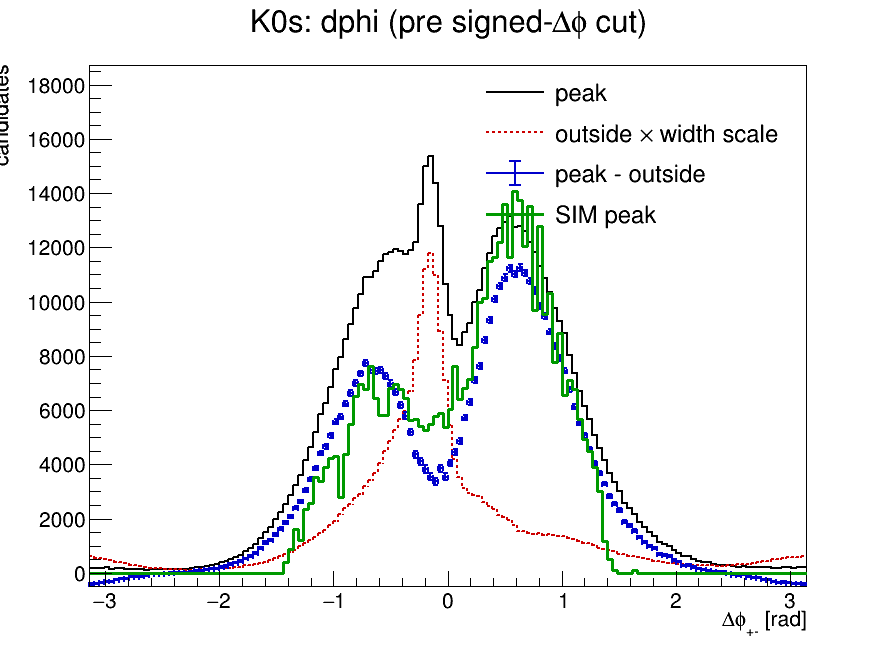

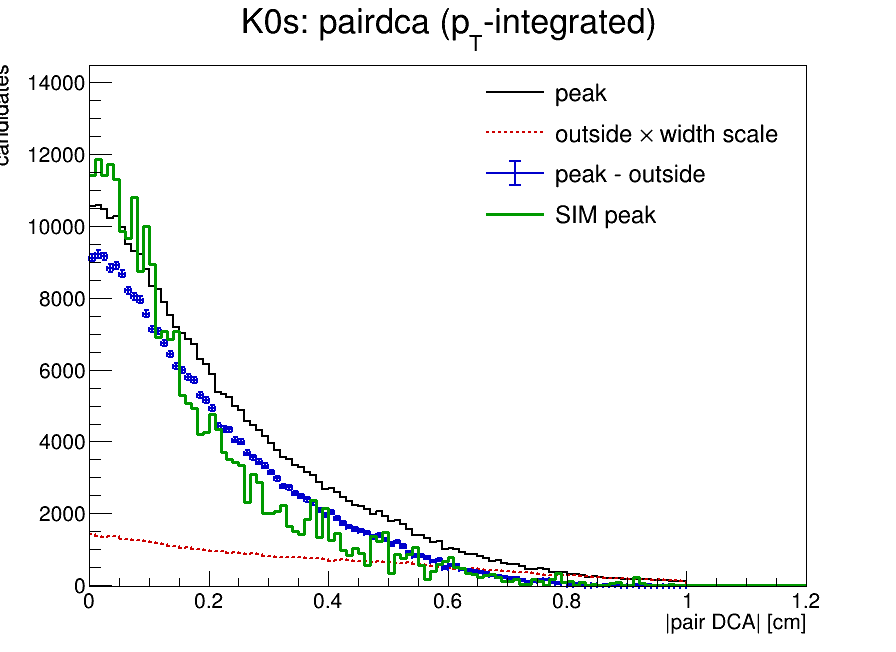

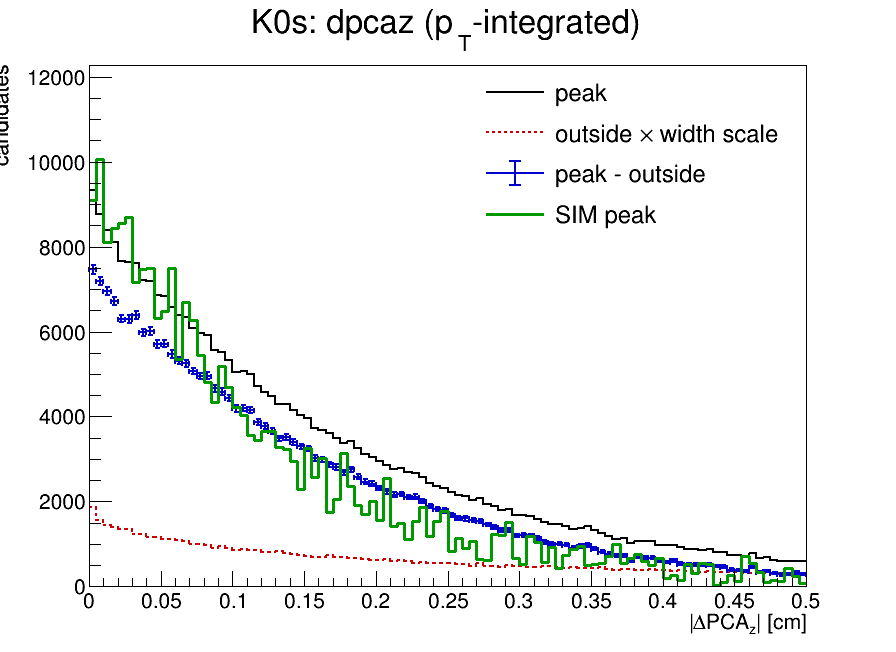

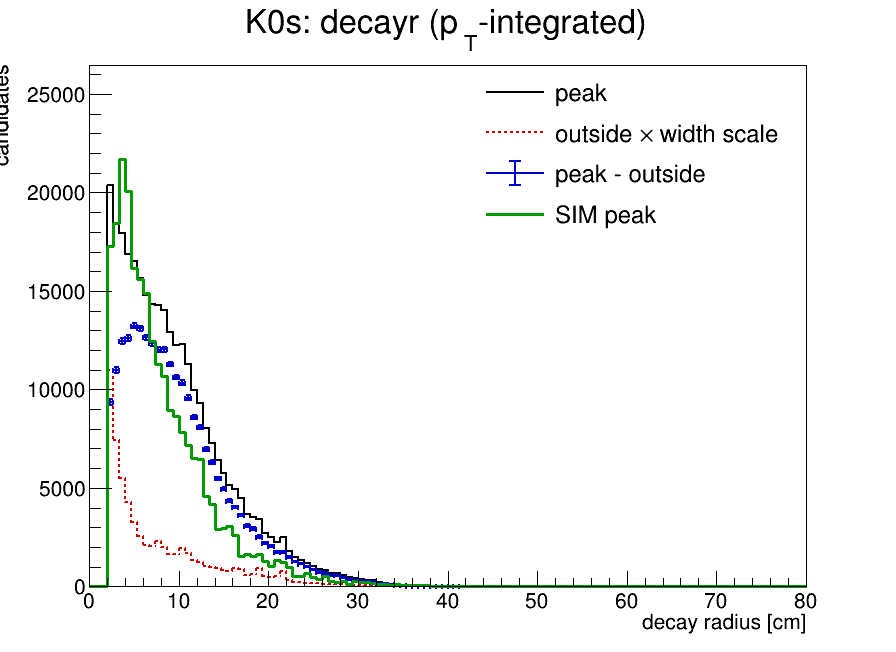

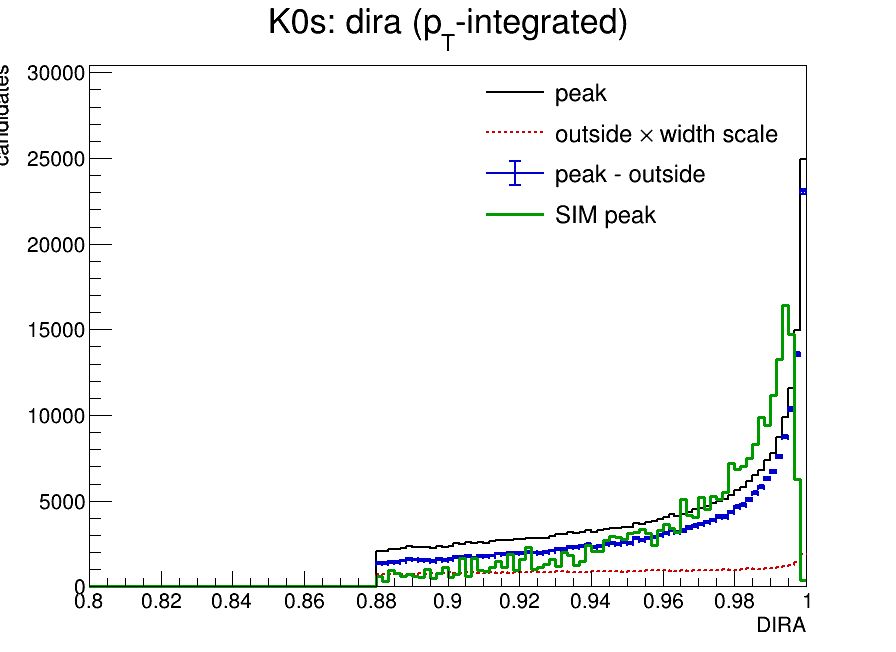

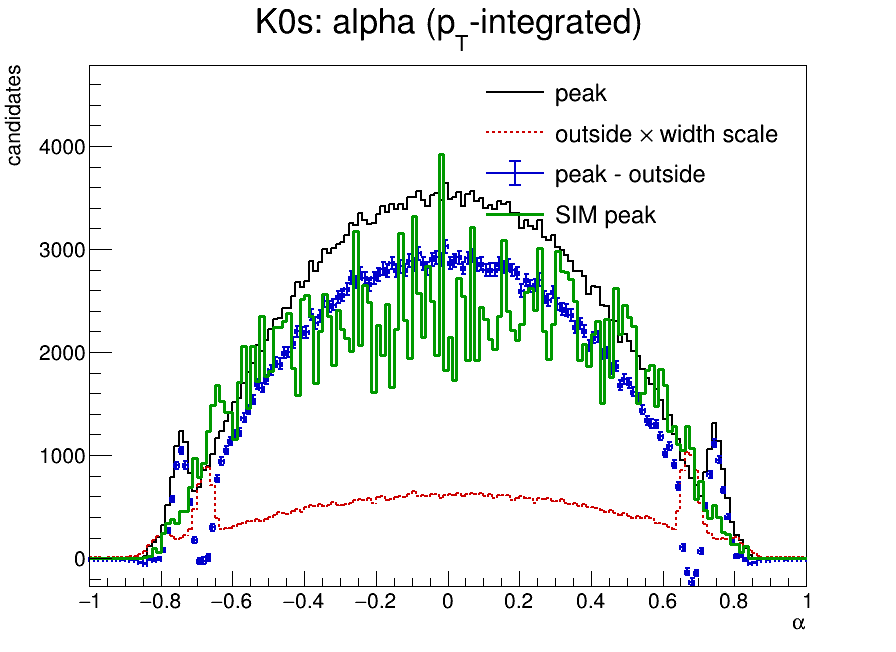

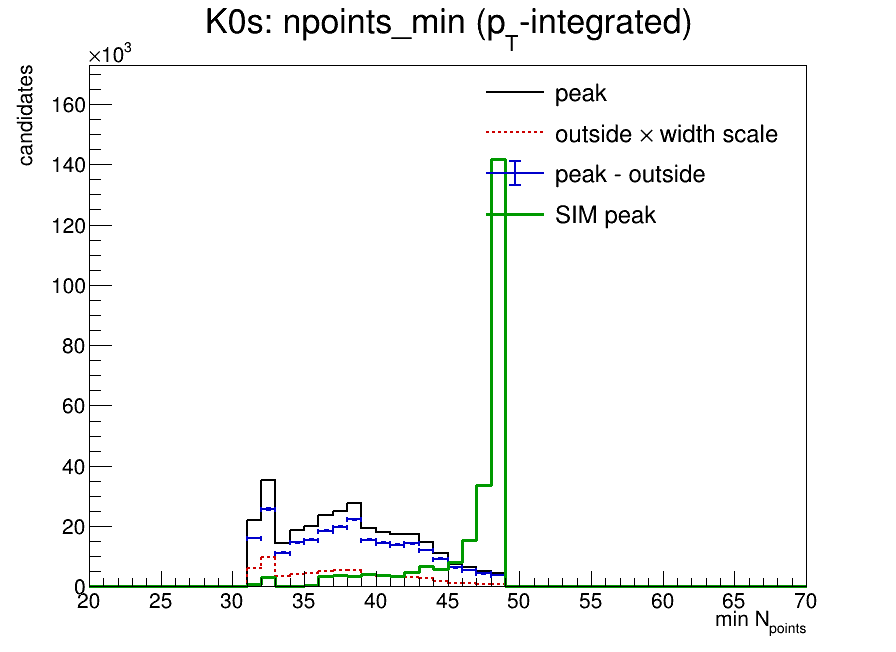

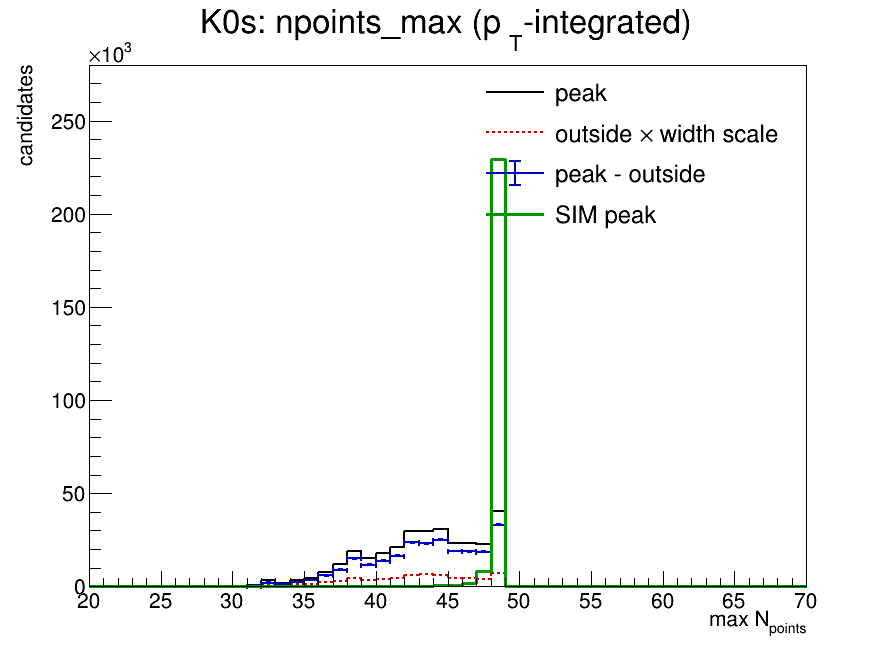

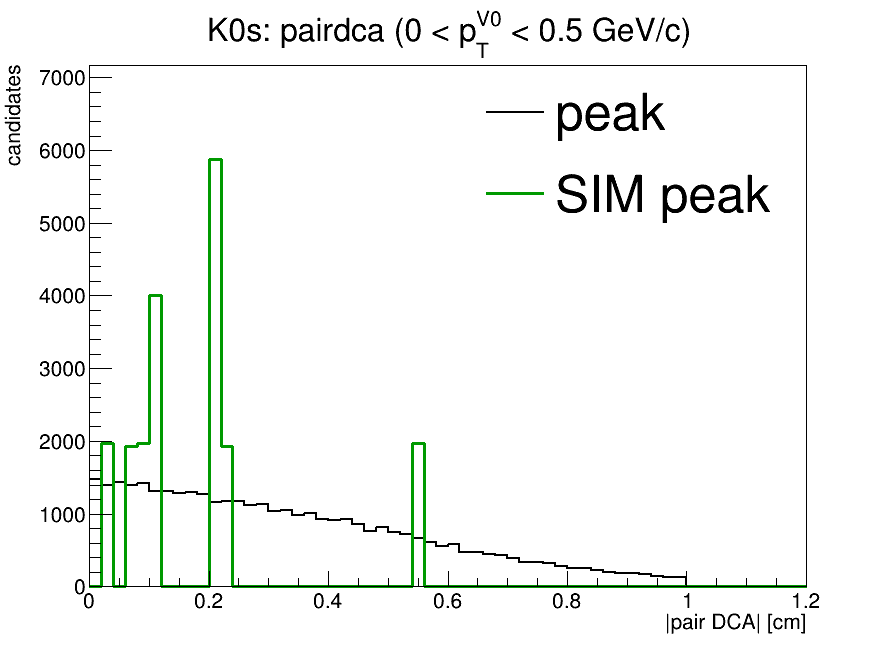

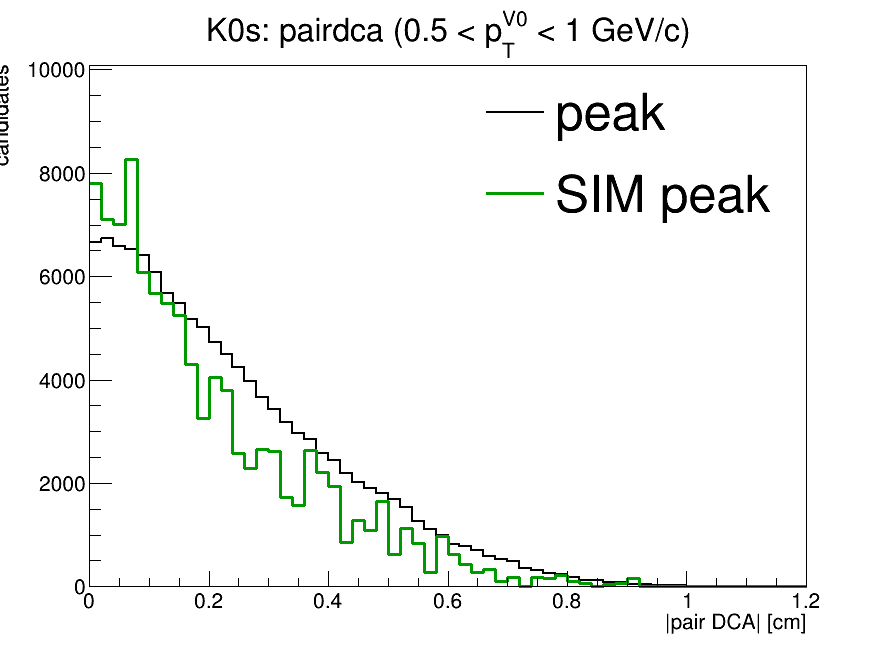

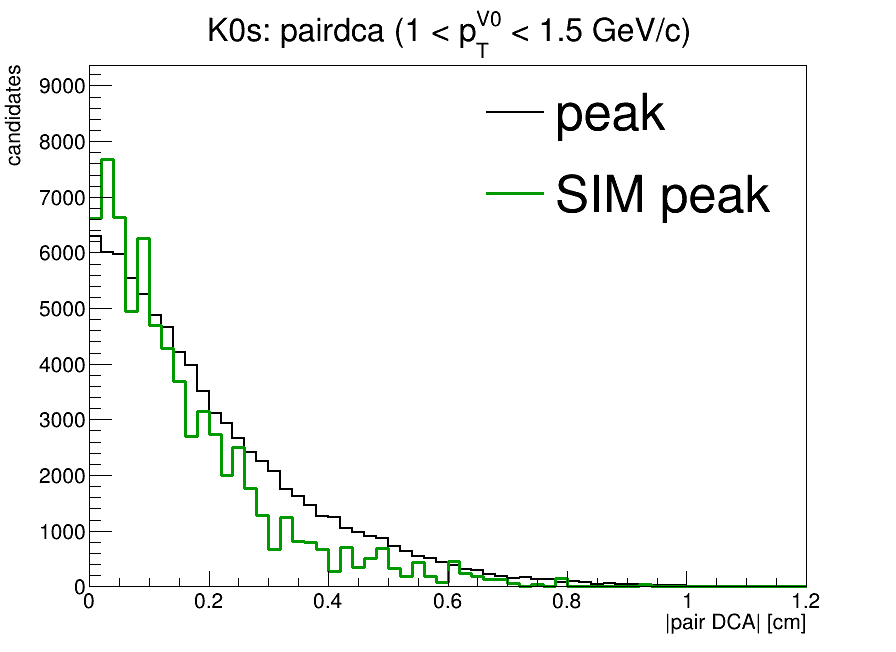

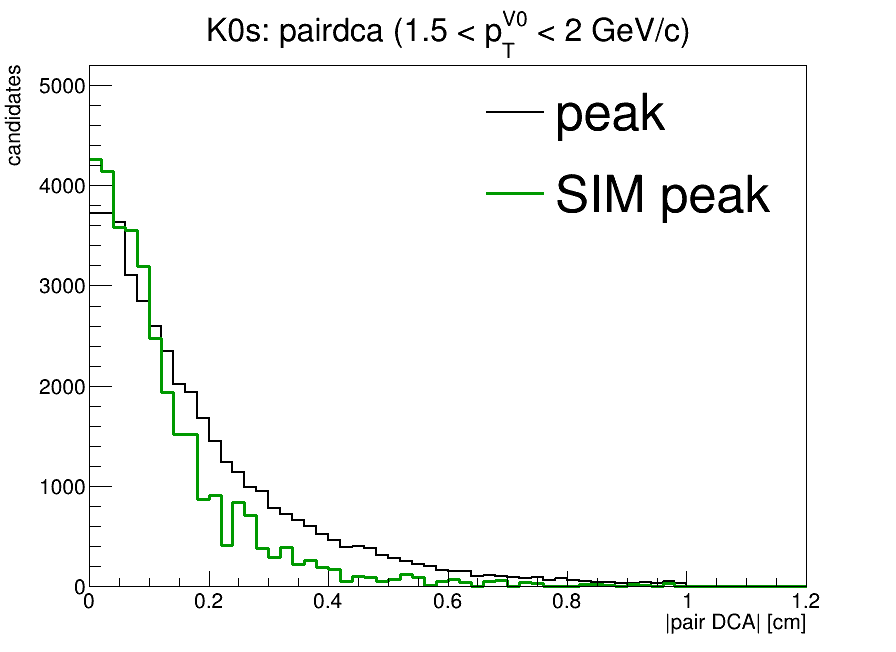

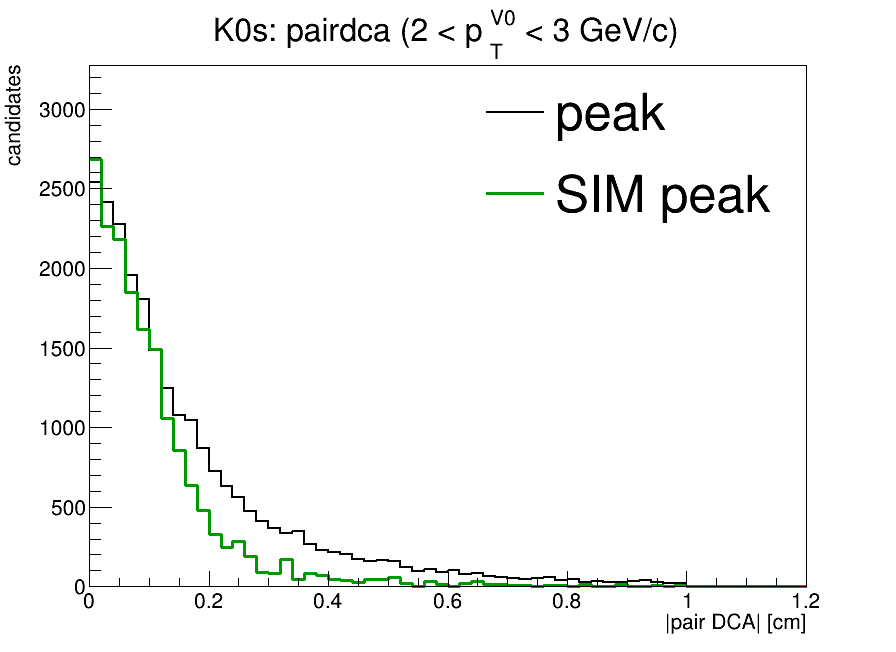

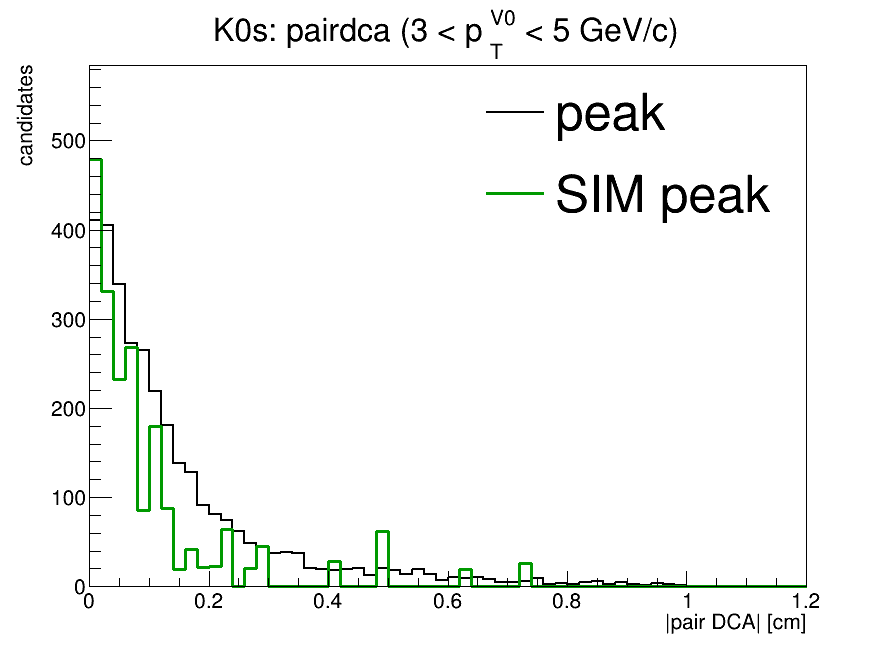

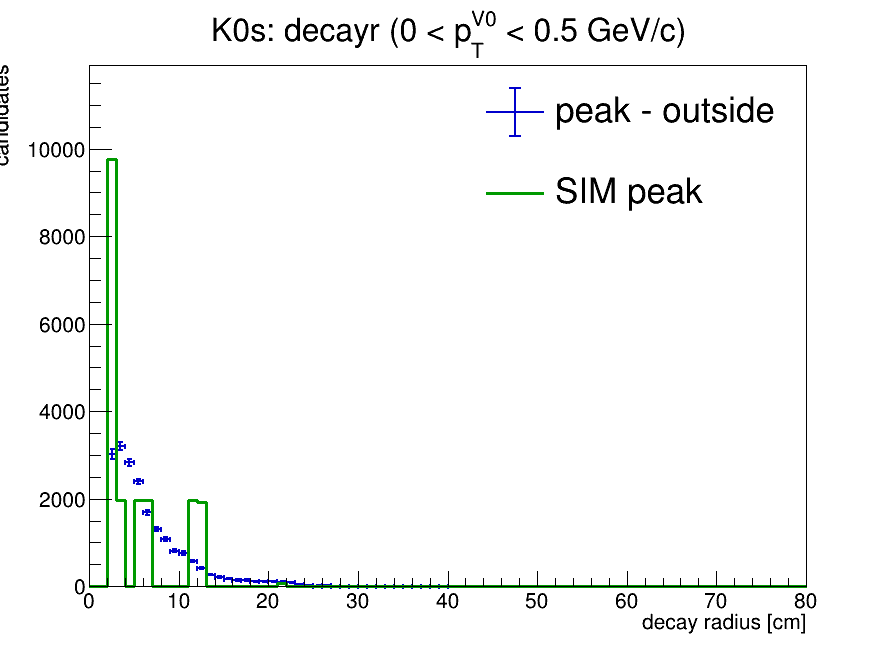

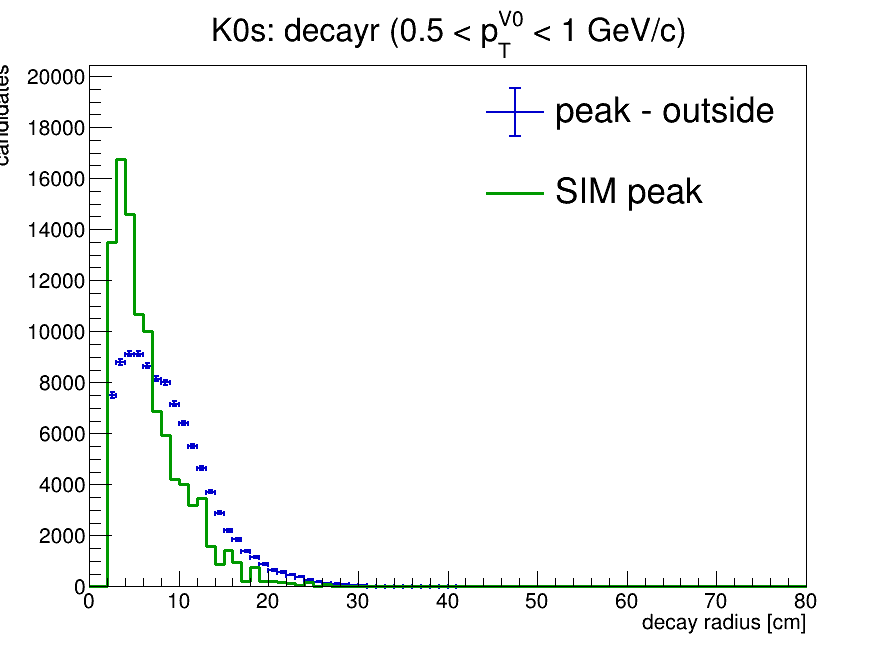

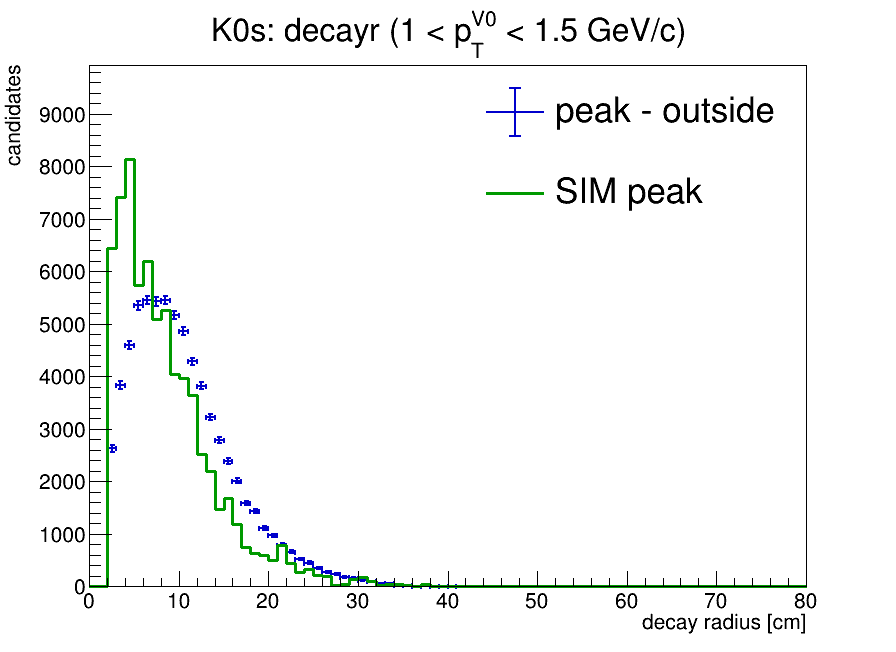

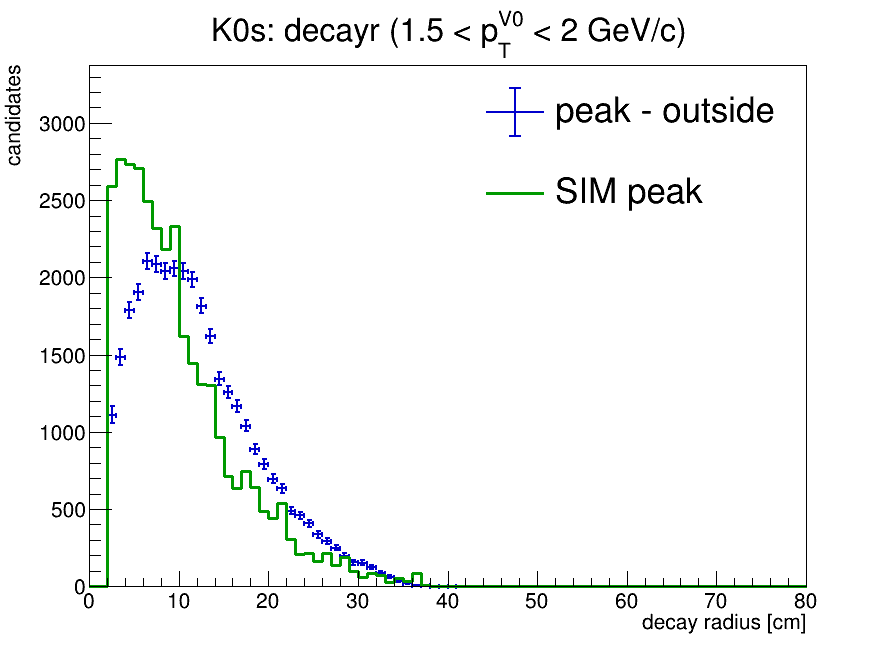

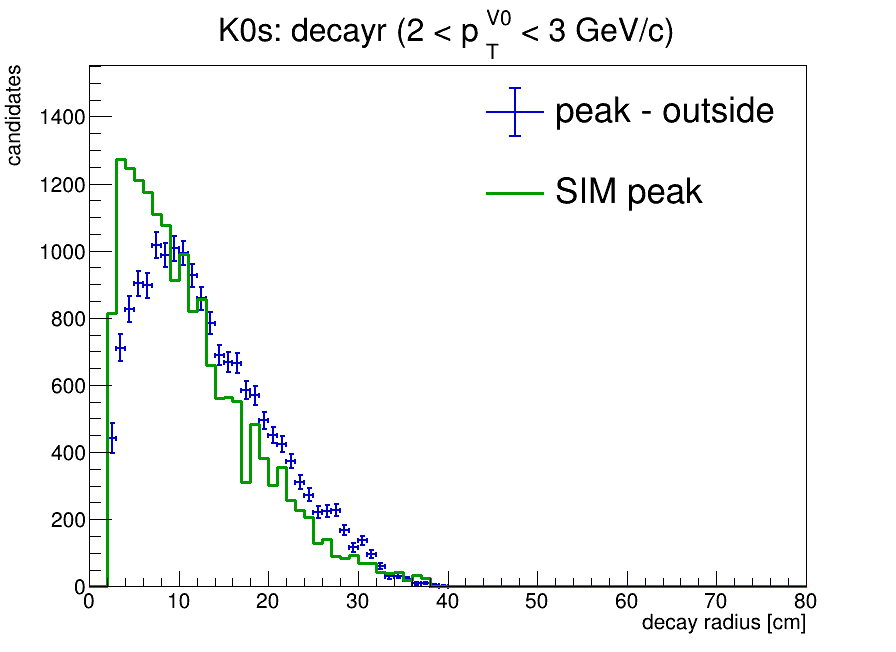

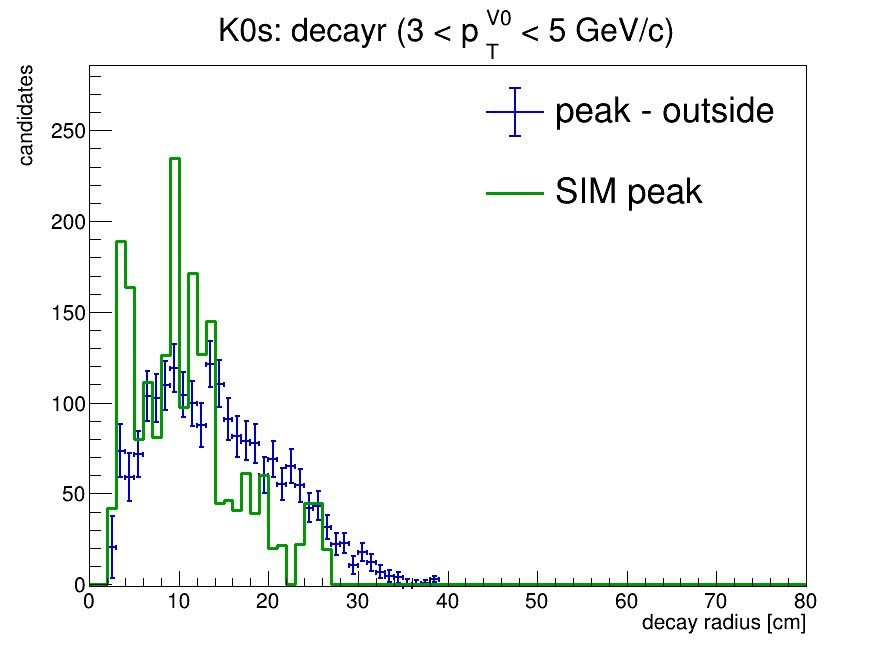

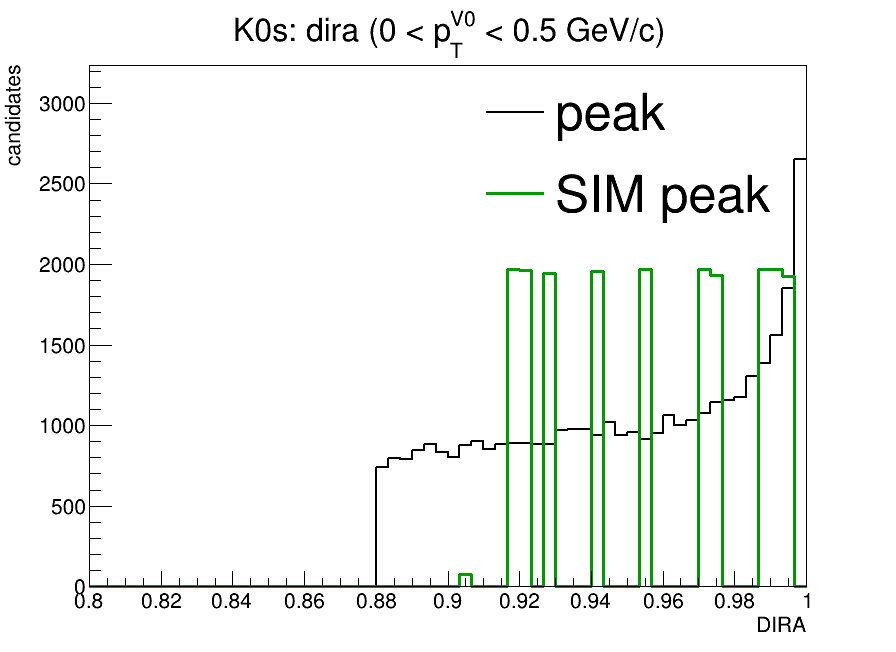

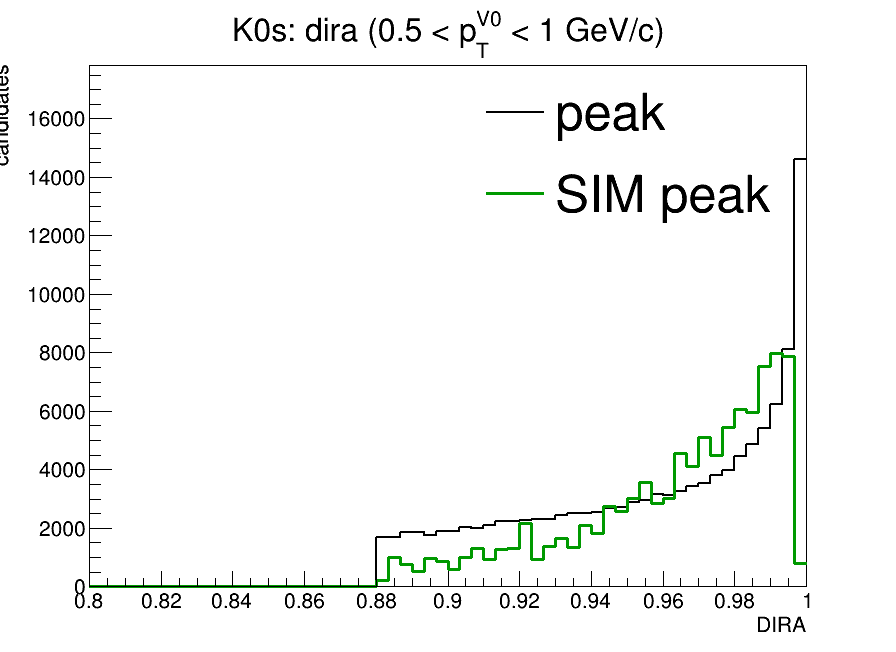

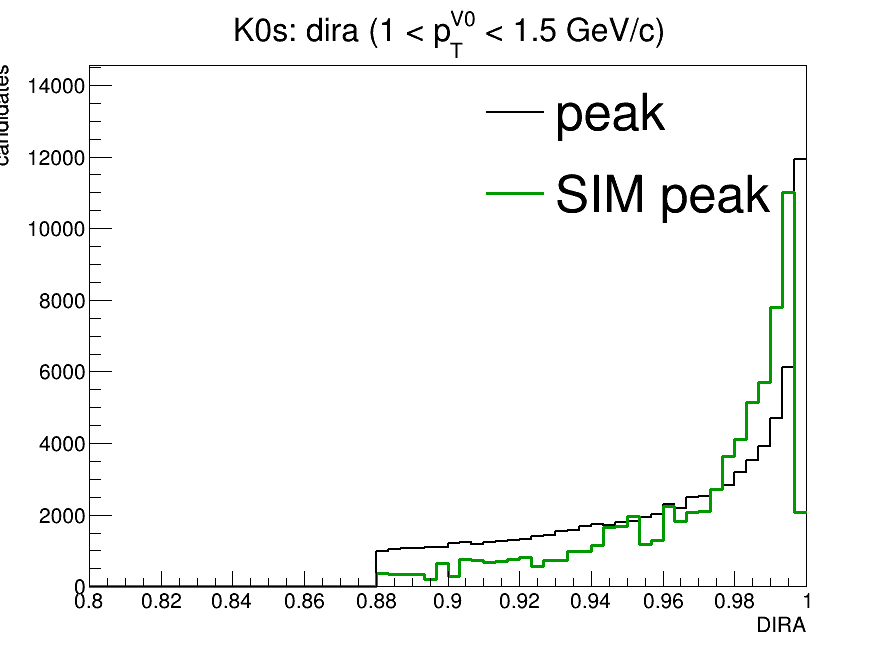

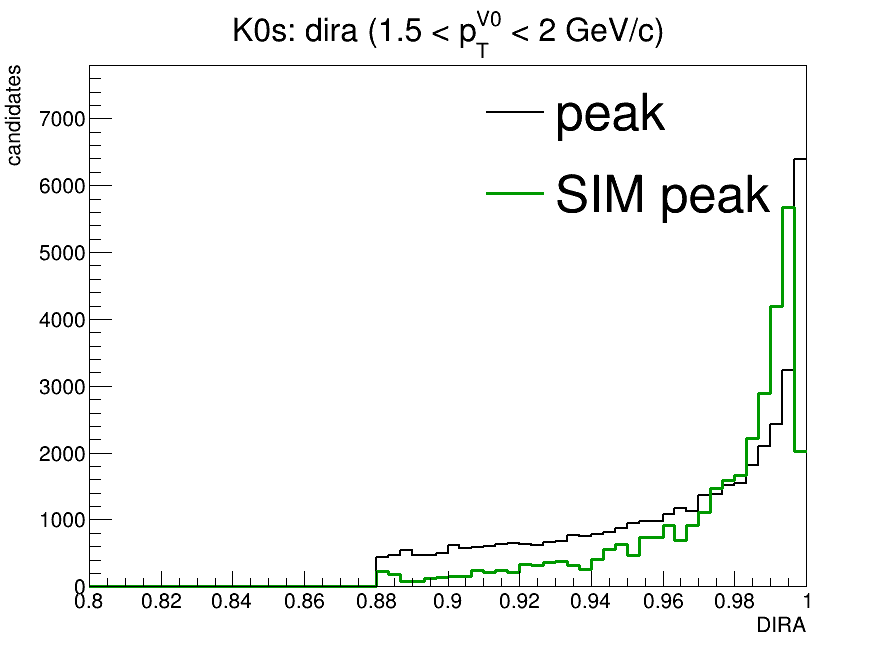

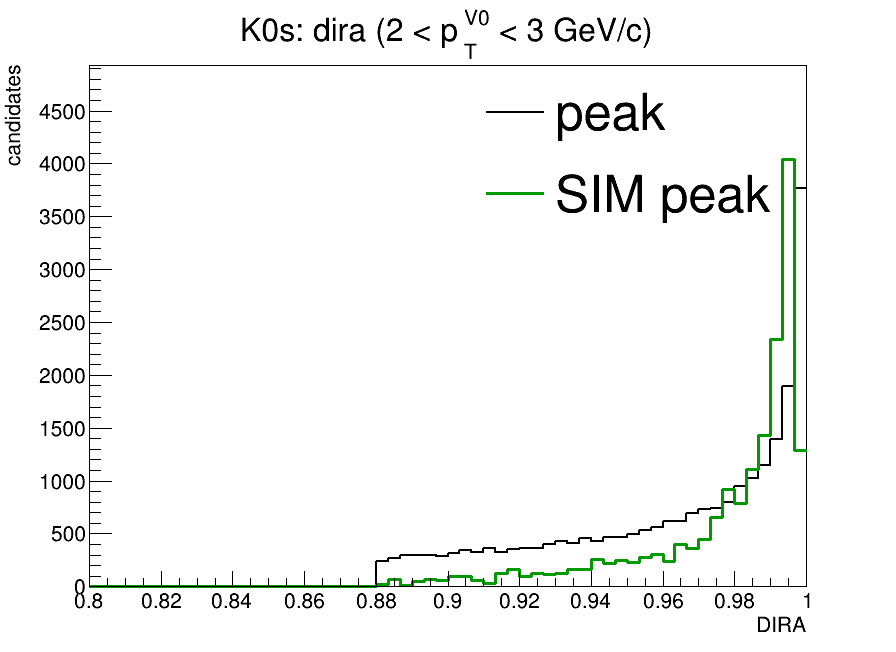

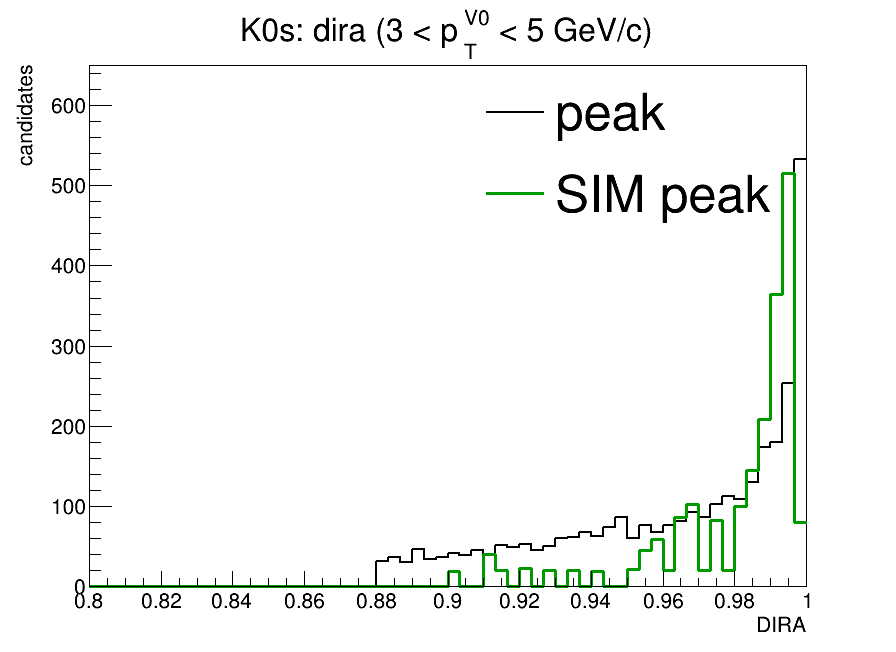

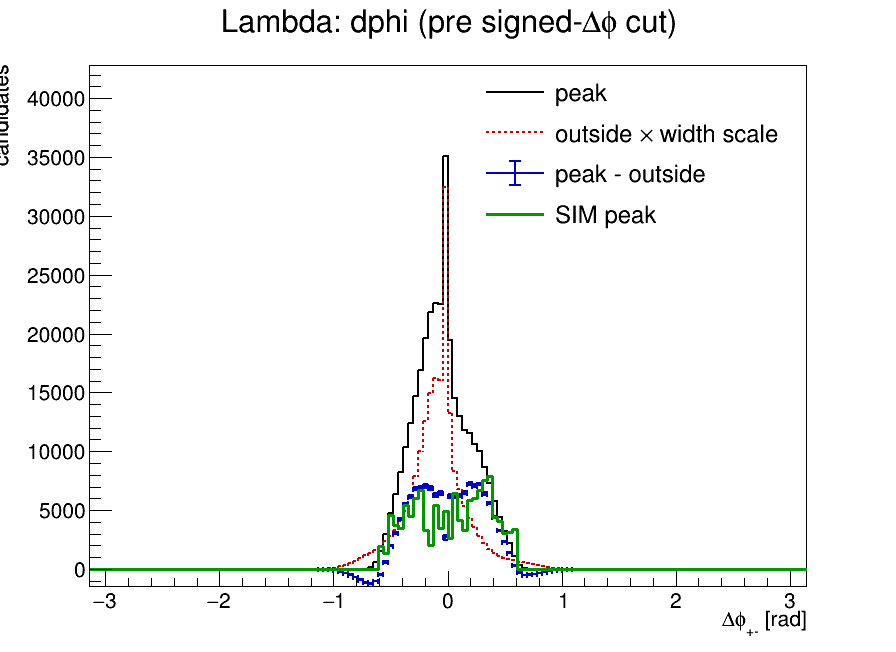

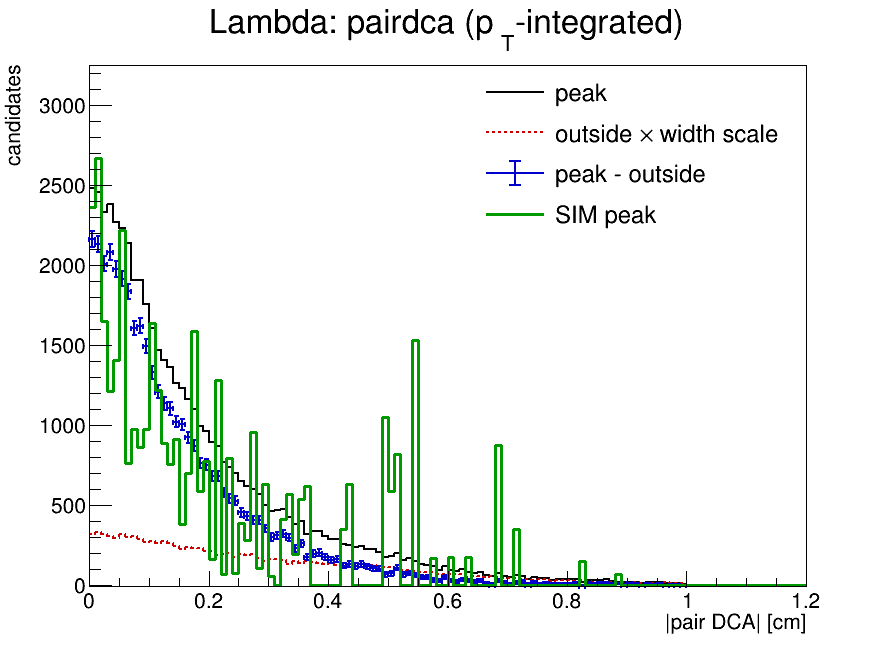

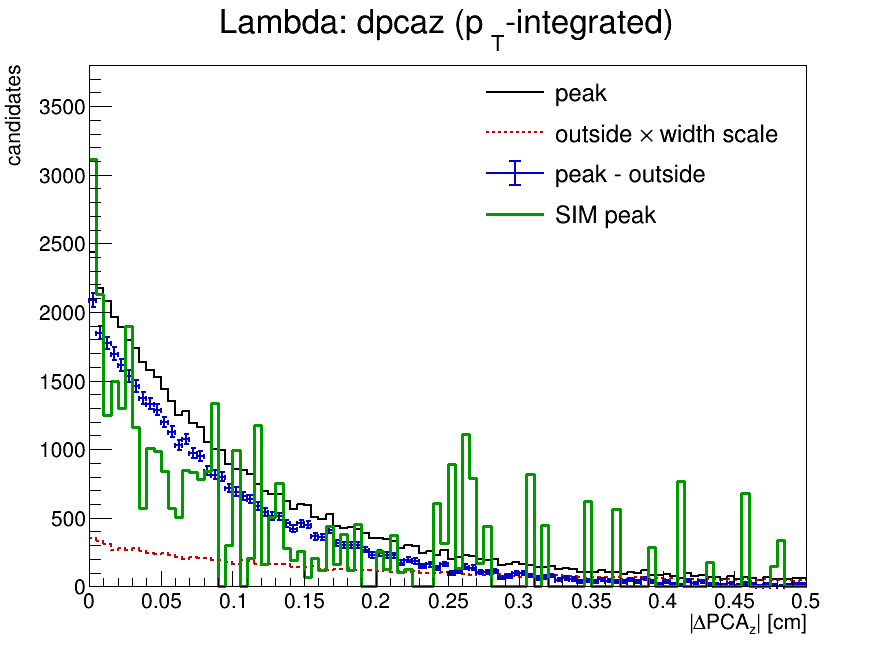

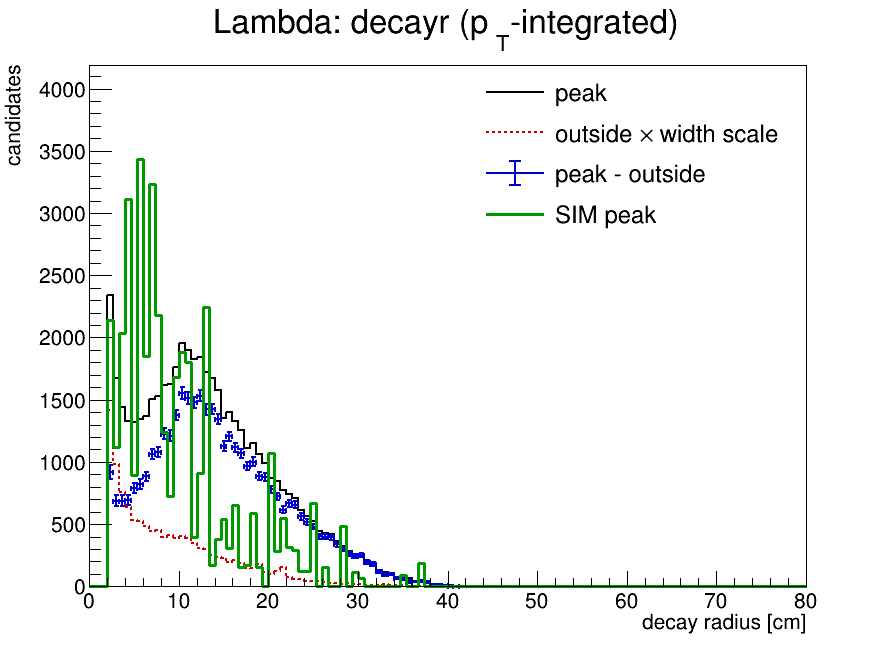

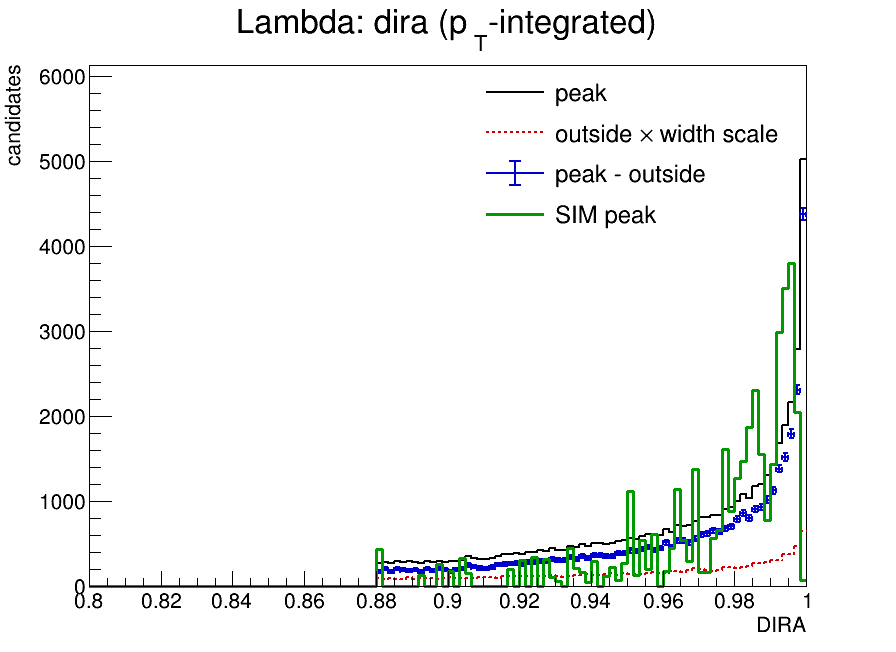

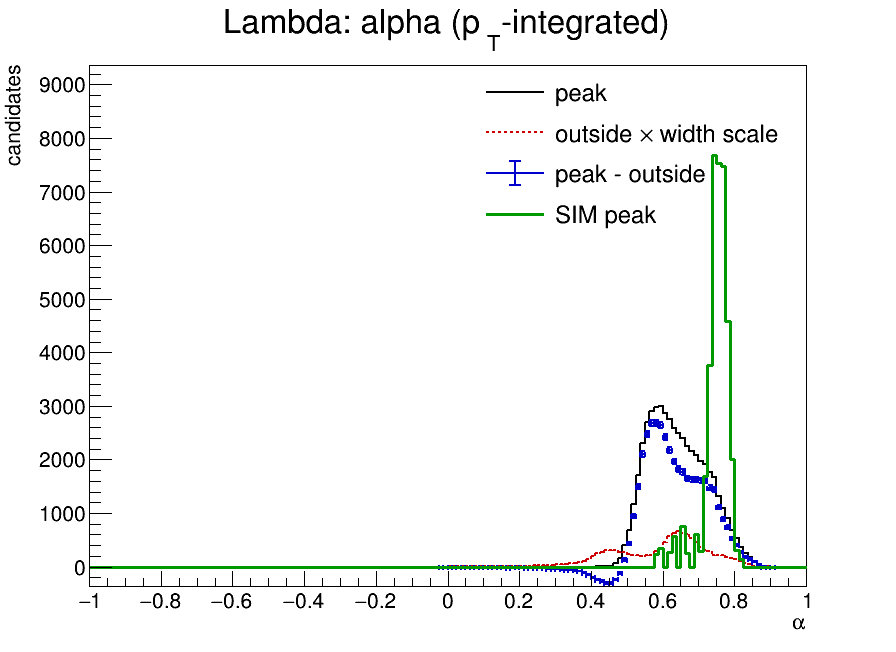

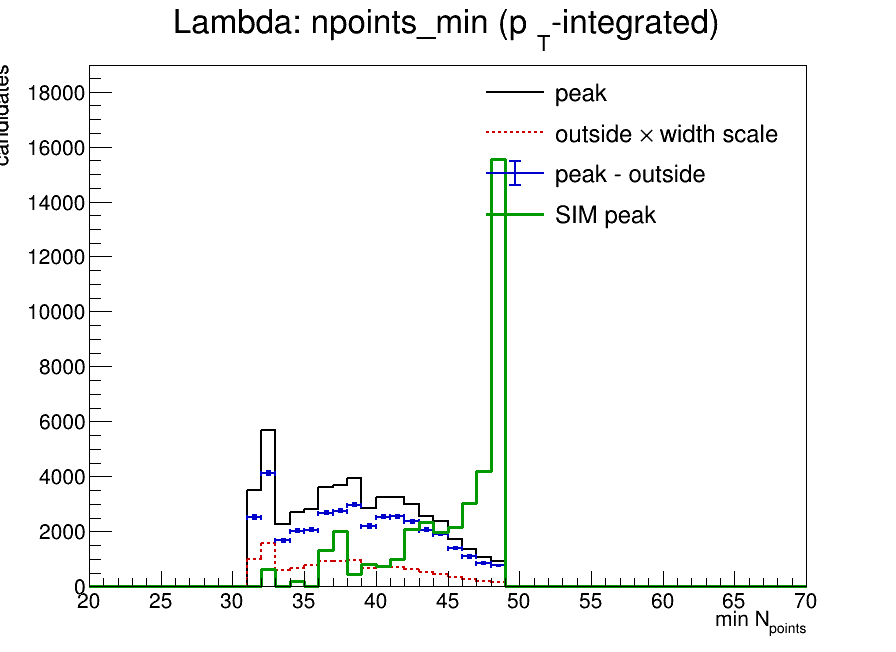

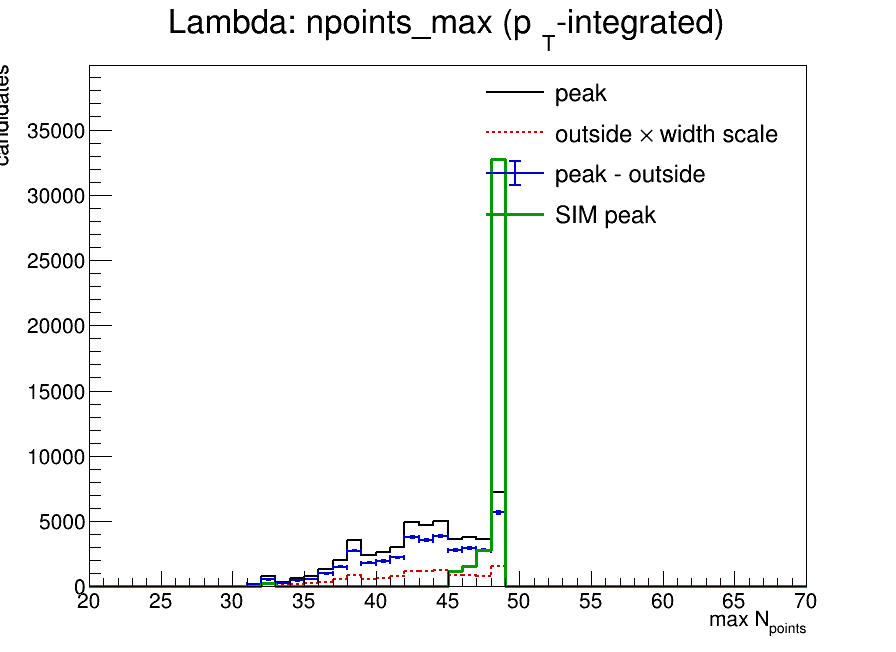

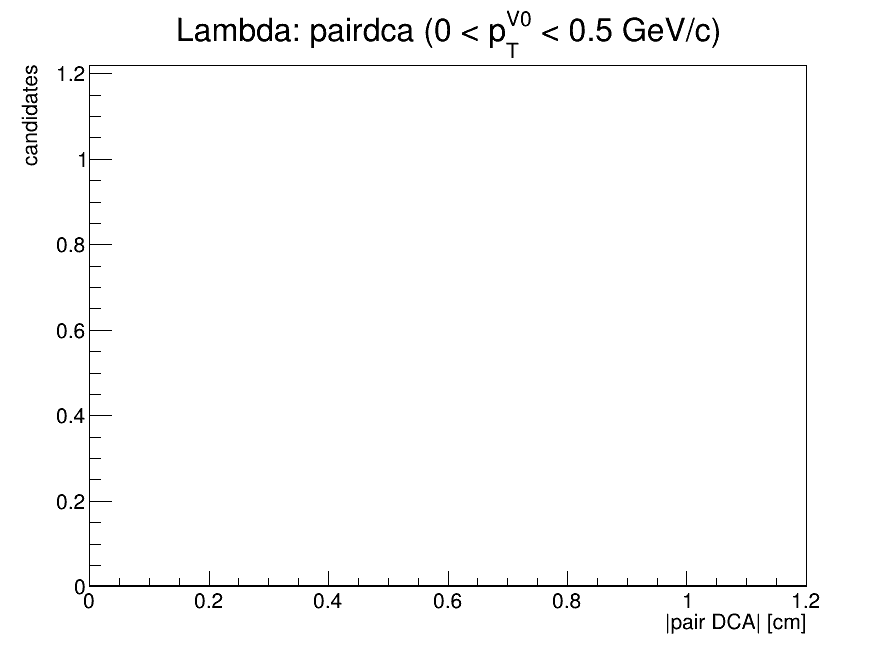

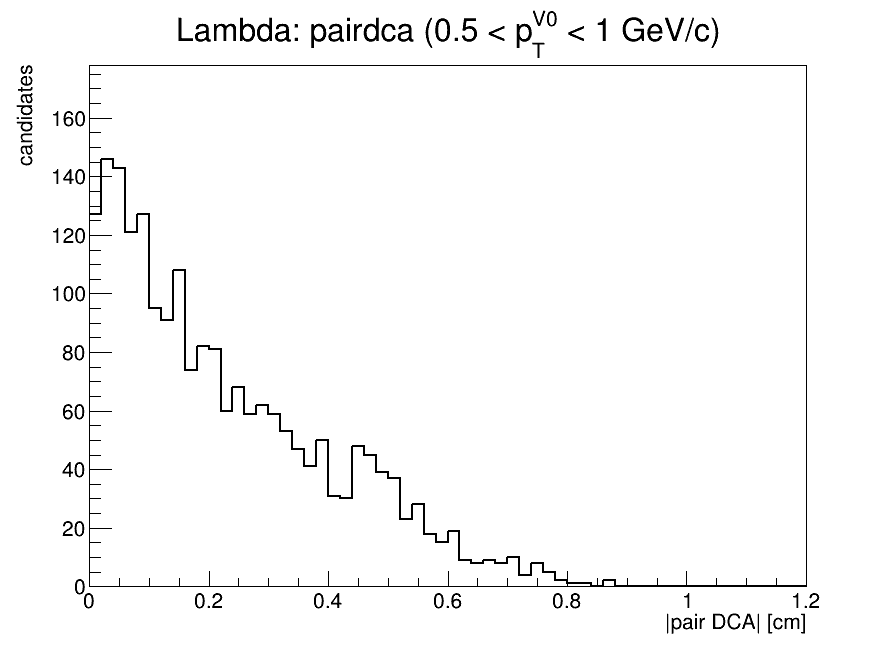

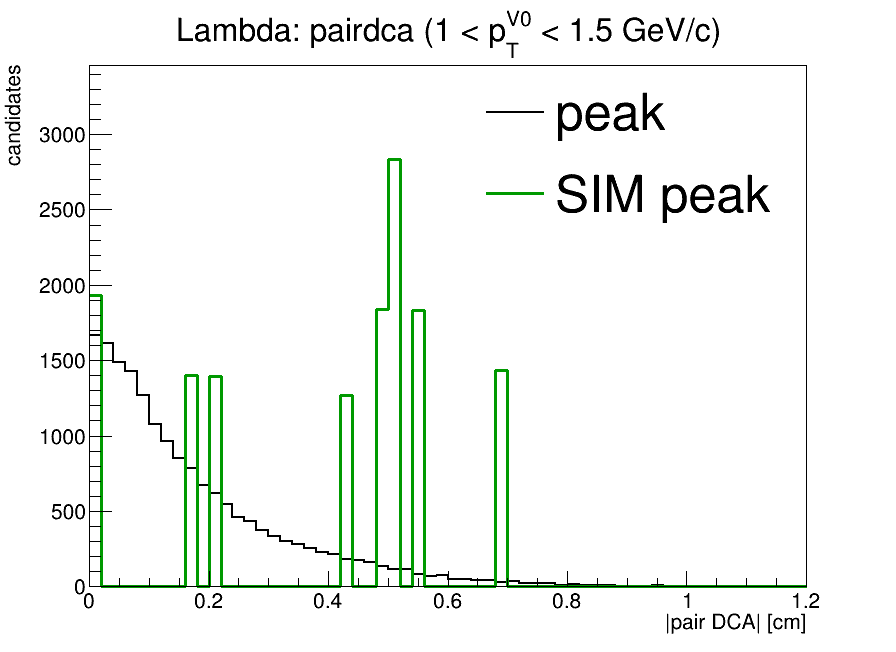

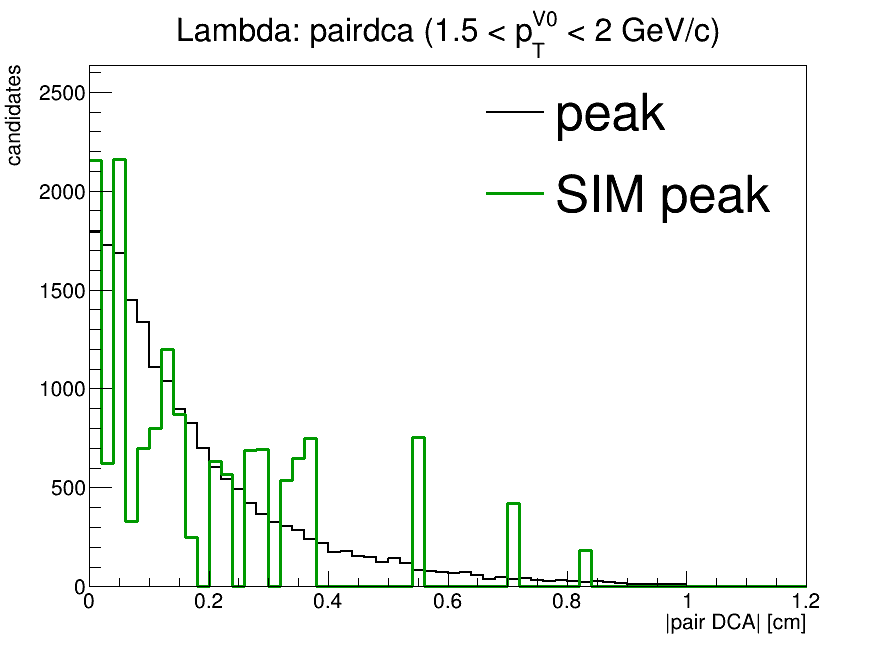

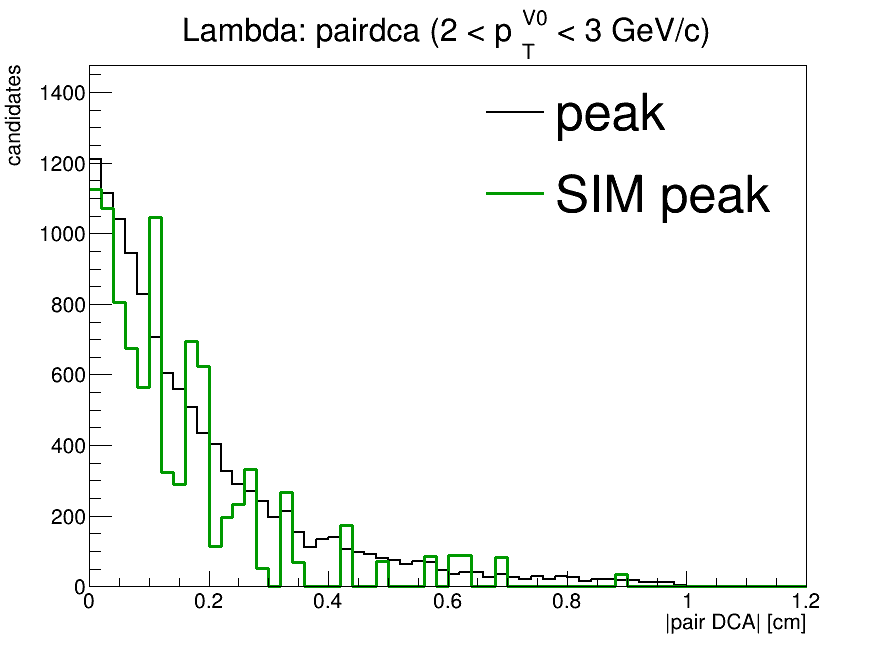

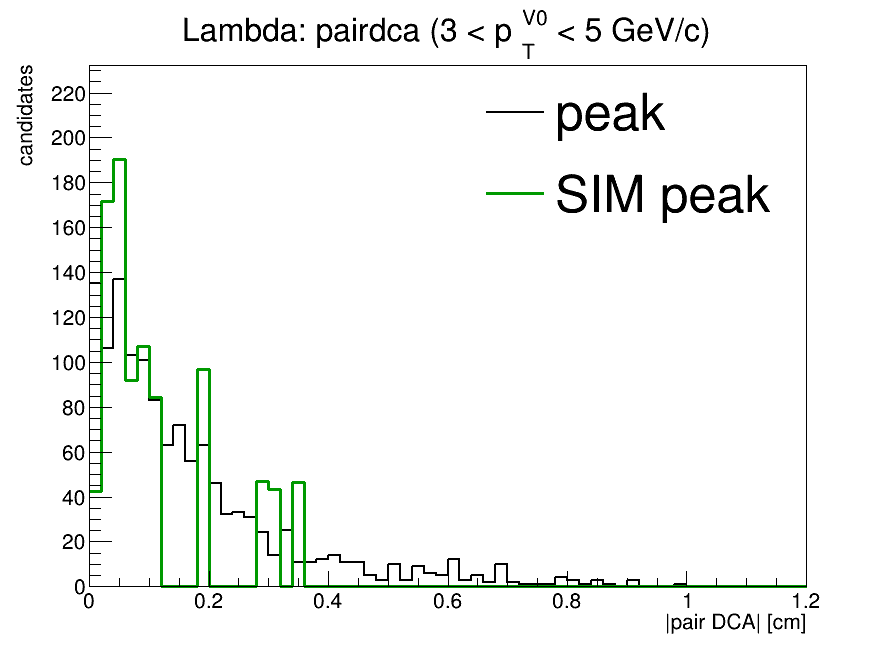

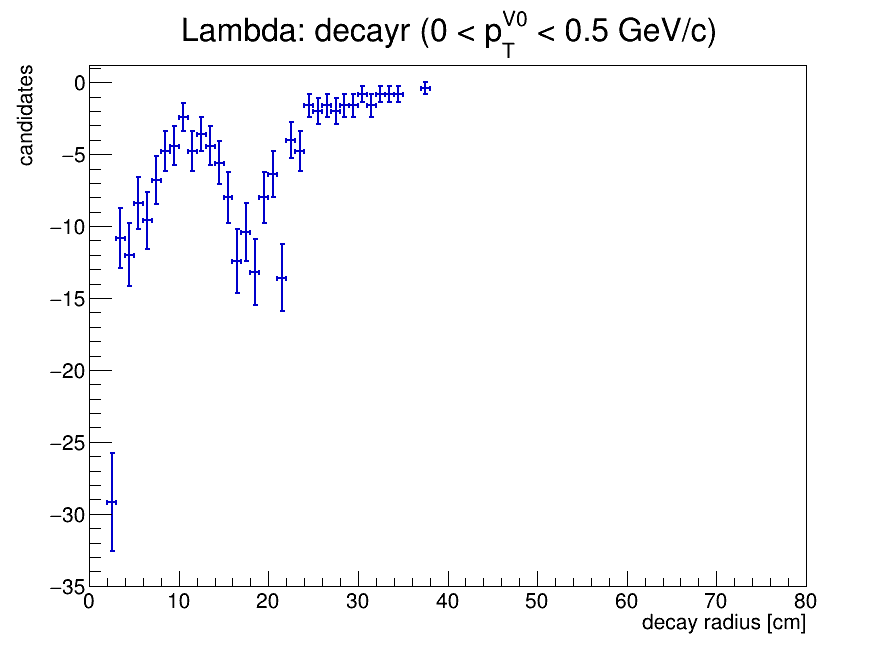

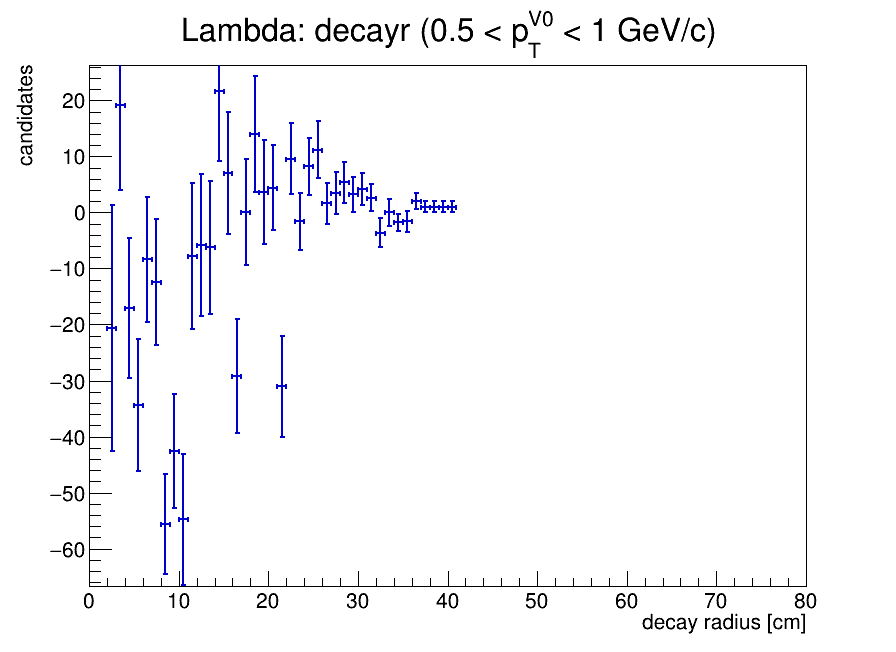

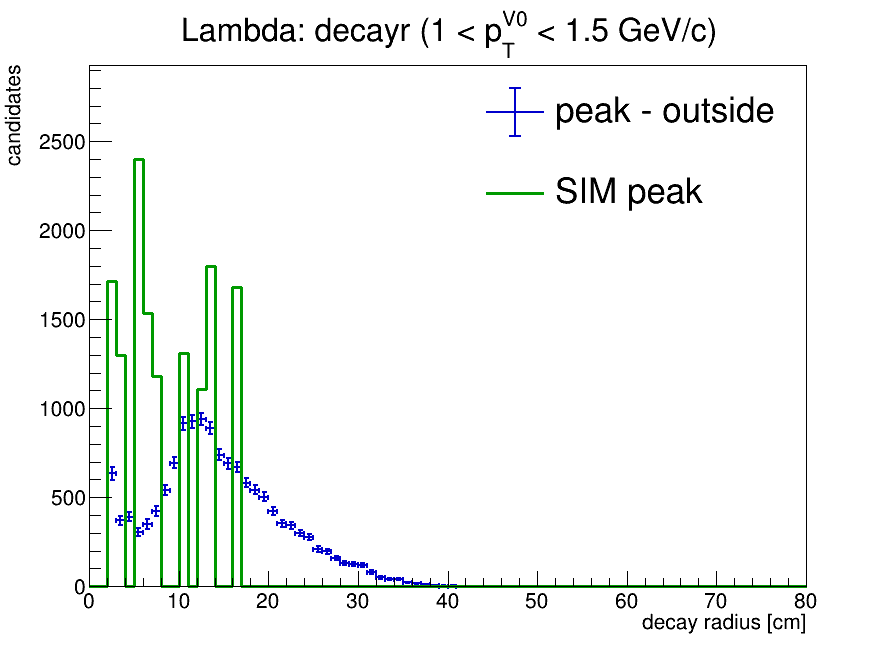

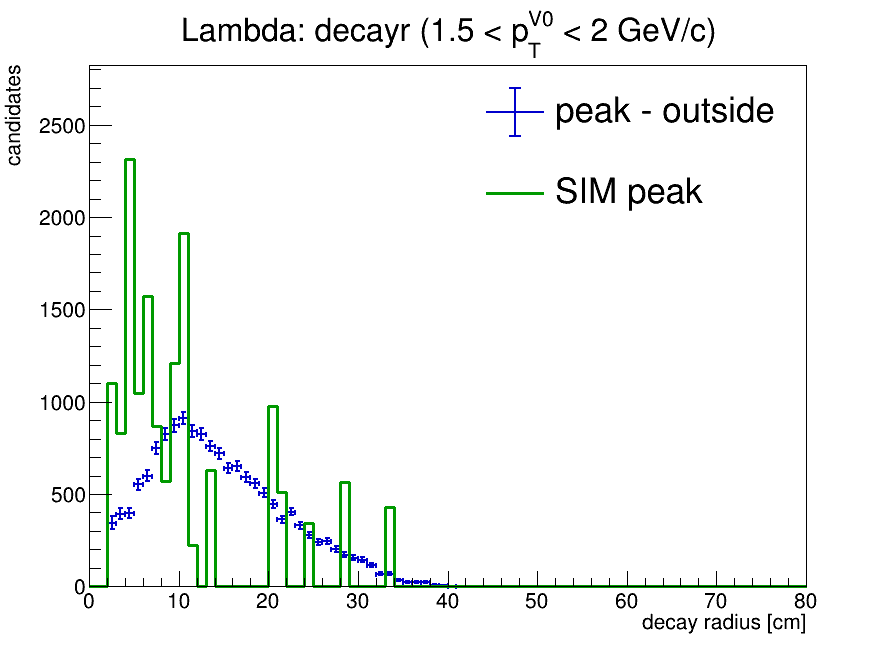

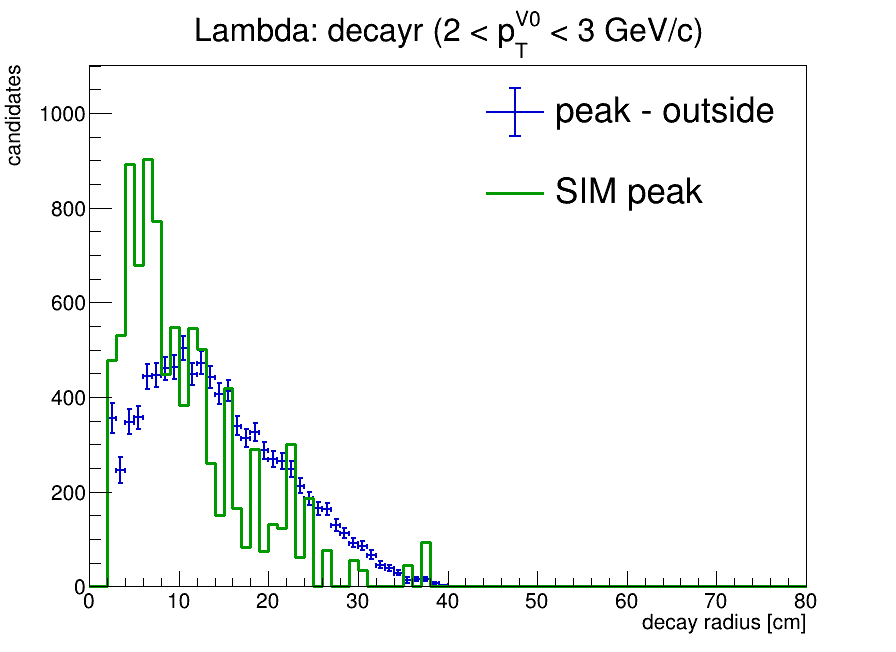

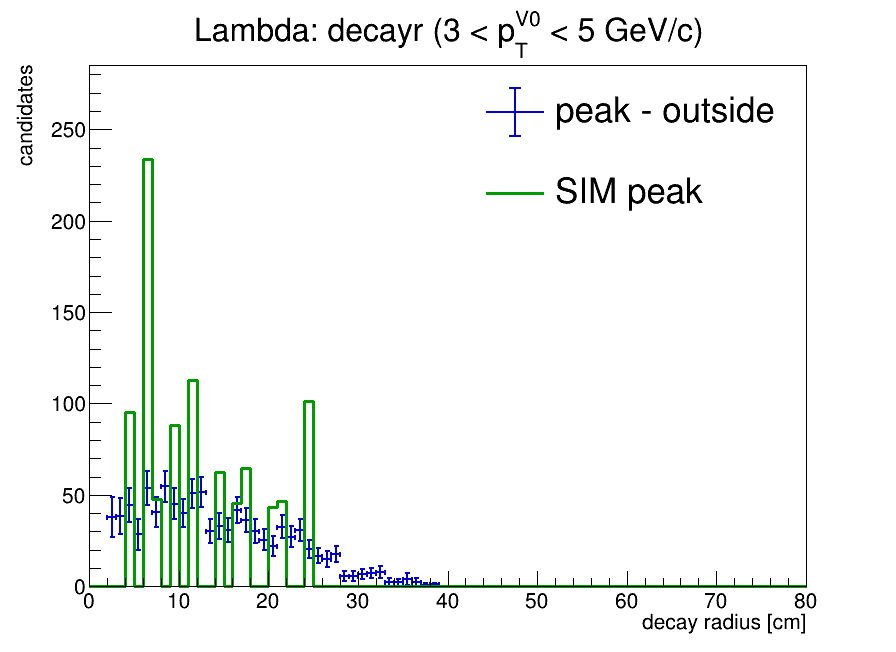

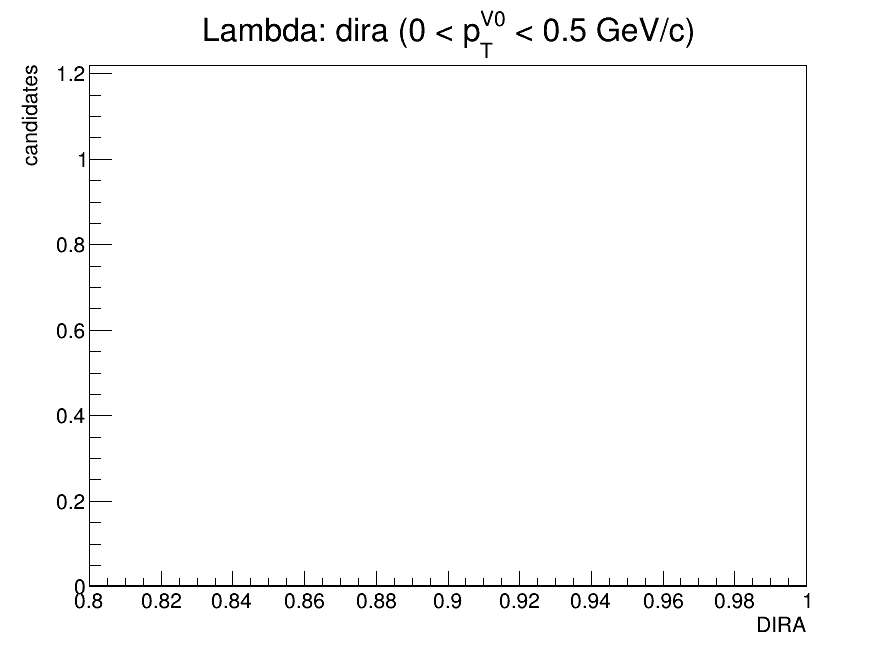

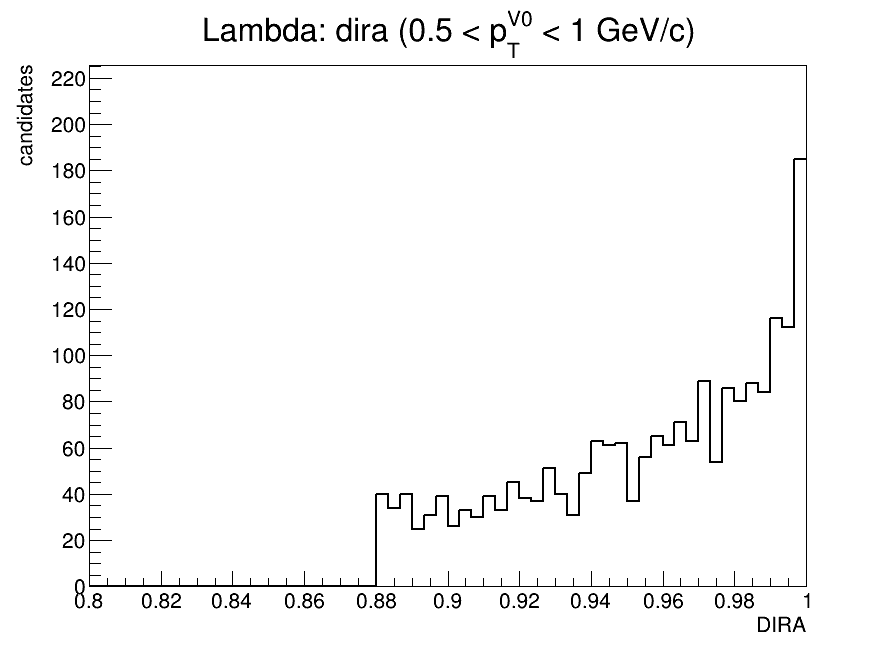

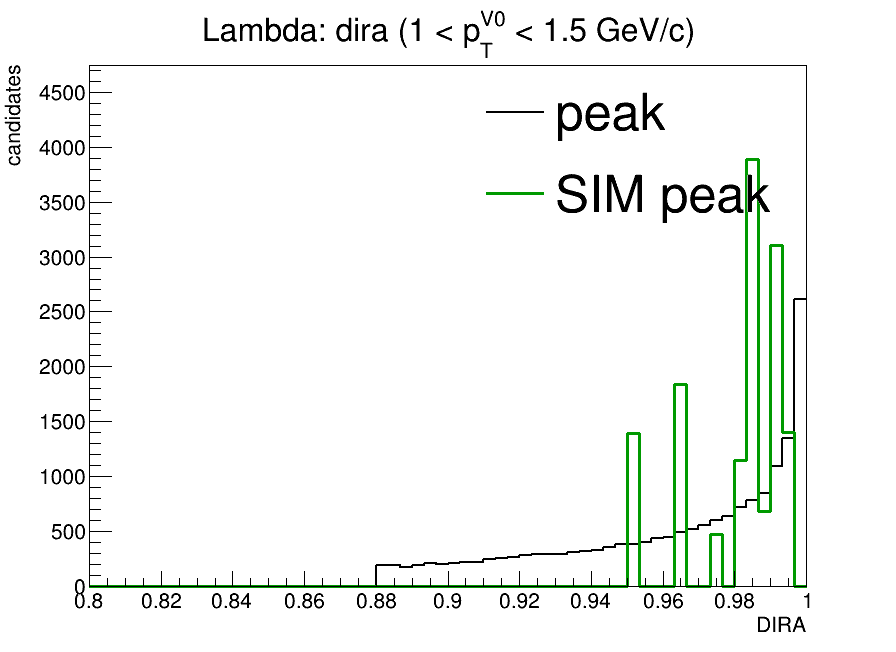

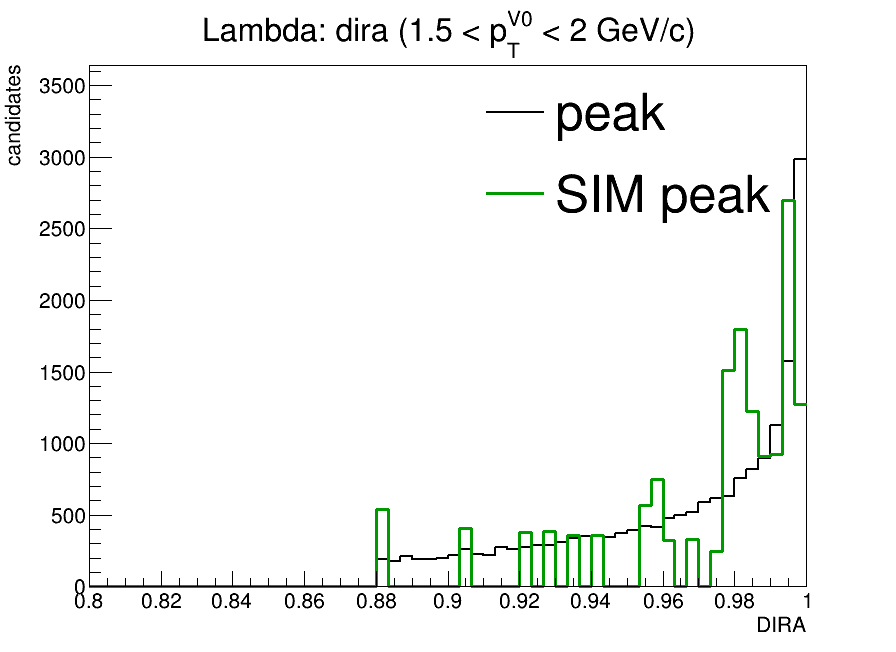

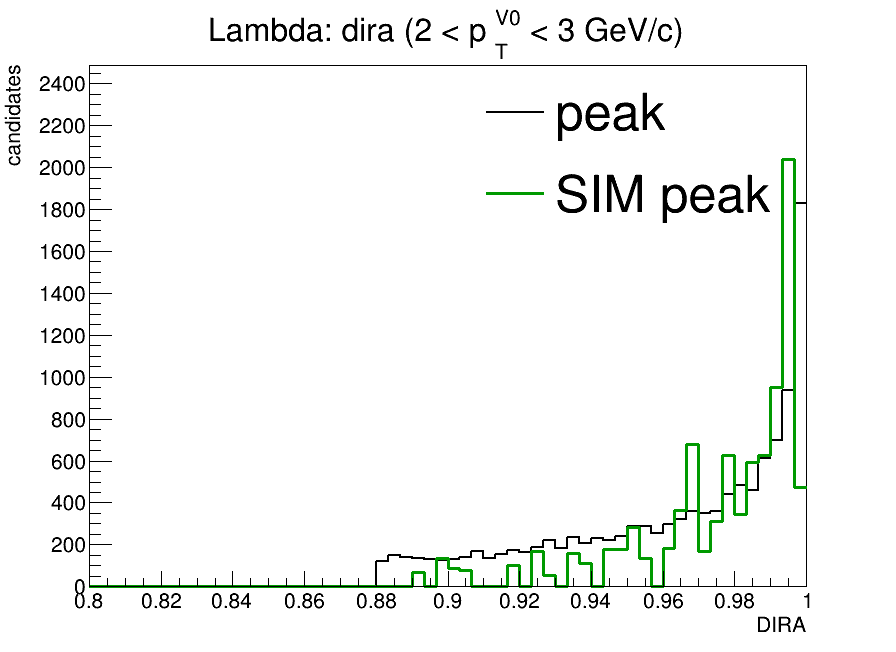

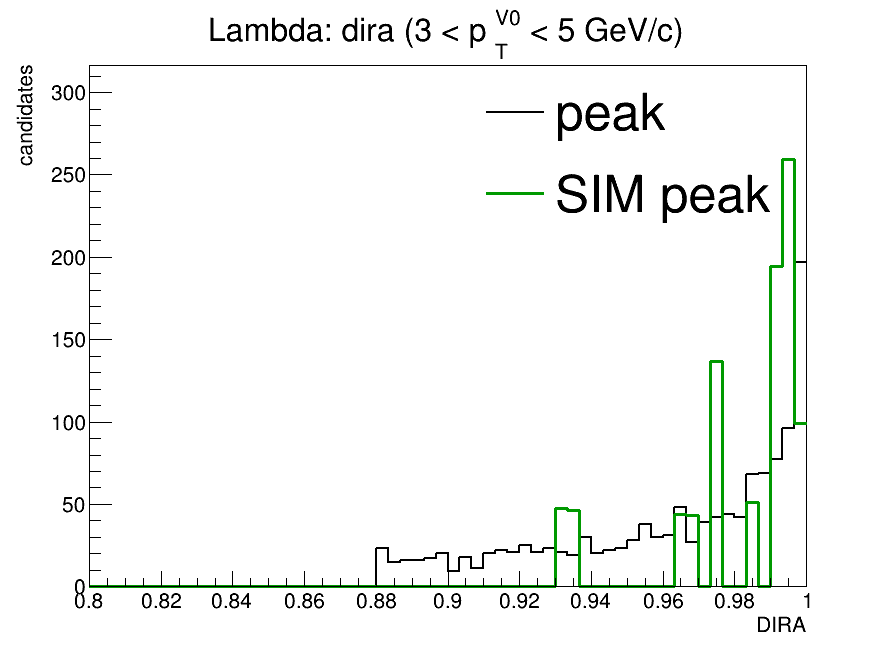

In [4]:
def parse(spec):
    p = spec.split(":")
    alias = p[0].strip()
    mode = p[1].strip() if len(p)>1 and p[1].strip() else "all"
    want_pt = len(p)>2 and p[2].strip().lower()=="pt"

    if alias not in ALIASES:
        raise KeyError(f"Unknown variable '{alias}'. Available: {', '.join(ALIASES)}")
    if mode not in ("all","pk","bg","sg"):
        raise ValueError(f"Bad mode '{mode}' in '{spec}'")
    return alias,mode,want_pt

pages = []
page_meta = []
warnings = []

for species in SPECIES:
    w = windows(species)
    print(f"\n{species}: peak={w['peak']}, sidebands={w['left']} + {w['right']}, scale={w['scale']:.6g}")

    for spec in PLOTS:
        alias,mode,want_pt = parse(spec)
        hname,kind = ALIASES[alias]

        if want_pt:
            if alias not in PT_MASS3:
                warnings.append(f"SKIP {species} {spec}: no mass x pT x variable histogram in this file")
                continue

            for pt in PT_BINS:
                hs = pt_triplet(species, alias, pt)

                sim_hs = sim_triplet(species, alias, kind, hname, True, pt)
                sim_norm = normalize_sim_to_data_signal(sim_hs, hs)

                print(f"  {spec:22s}  pT={pt}: pk[{hist_info(hs['pk'])}]  bg[{hist_info(hs['bg'])}]  sg[{hist_info(hs['sg'])}]")
                if sim_hs is not None and sim_norm is not None:
                    print(f"    SIM scale={sim_norm:.5g}, SIM pk[{hist_info(sim_hs['pk'])}]")

                subtitle = f"{pt[0]:g} < p_{{T}}^{{V0}} < {pt[1]:g} GeV/c"
                c = draw_1d(species, alias, hs, mode, subtitle, sim_hs, SIM_MODE, sim_norm)
                tag = f"{alias}_{mode}_pt_{pt[0]:g}_{pt[1]:g}"

                pages.append(c)
                page_meta.append((species, tag, hs, sim_hs, sim_norm))
            continue

        if kind == "pre_dphi":
            hs = pre_dphi_triplet(species)
            sim_hs = sim_triplet(species, alias, kind, hname)
            sim_norm = normalize_sim_to_data_signal(sim_hs, hs)
            c = draw_1d(species, alias, hs, mode, "pre signed-#Delta#phi cut", sim_hs, SIM_MODE, sim_norm)
        else:
            hs = regular_triplet(species, hname)

            # "On top" is meaningful for 1D curves. Keep existing 2D behavior unchanged.
            if kind == "h1":
                sim_hs = sim_triplet(species, alias, kind, hname)
                sim_norm = normalize_sim_to_data_signal(sim_hs, hs)
                c = draw_1d(species, alias, hs, mode, "p_{T}-integrated", sim_hs, SIM_MODE, sim_norm)
            else:
                sim_hs = None
                sim_norm = None
                c = draw_2d(species, alias, hs, mode, "p_{T}-integrated")
                if PLOT_SIM:
                    warnings.append(f"SIM overlay not drawn for 2D plot {species} {alias}")

        print(f"  {spec:22s}  pk[{hist_info(hs['pk'])}]  bg[{hist_info(hs['bg'])}]  sg[{hist_info(hs['sg'])}]")
        if sim_hs is not None and sim_norm is not None:
            print(f"    SIM scale={sim_norm:.5g}, SIM pk[{hist_info(sim_hs['pk'])}]")

        tag = f"{alias}_{mode}_integrated"
        pages.append(c)
        page_meta.append((species, tag, hs, sim_hs, sim_norm))

print_pdf(pages, PDF)

for c,(species,tag,hs,sim_hs,sim_norm) in zip(pages,page_meta):
    write_objects(species, tag, hs, c, sim_hs, sim_norm)

fout.Write()
fout.Close()

print(f"\nWrote {len(pages)} pages -> {PDF}")
print(f"Wrote derived histograms/canvases -> {ROOT_OUT}")

if PLOT_SIM:
    print(f"Simulation overlay: {FILE_SIM}")
    print(f"SIM_MODE = {SIM_MODE}; normalization = SIM peak integral -> DATA (peak - sidebands) integral")

if warnings:
    print("\nWarnings:")
    for x in warnings:
        print("  ", x)

if SHOW and pages:
    display(pages[0])
